In [1]:
from common import *

get(
    "machinable.index",
    "./index",
).__enter__()


machinable.index [857f6f]

In [6]:
_ca1_samplers = get("interface._ca1_samplers")

globus_download(_ca1_samplers)

numprocs=1


In [7]:
_ca1_optimizers = get("interface._ca1_optimizers")

globus_download(_ca1_optimizers)

2025-07-17 20:26:26.684377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-17 20:26:26.705520: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-17 20:26:26.705556: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-17 20:26:26.719609: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-17 20:26:27.789488: W tensorflow/compiler/tf

In [8]:
nadirs = population_nadirs(_ca1_samplers, _ca1_optimizers)

In [9]:
hvs = {}

for p in _ca1_samplers.populations():
    experiments = _ca1_samplers.components.filter(lambda x: p in x.label())
    num_initial = experiments[0].num_initial_samples
    nadir = nadirs[p]
    for experiment in experiments:
        name = experiment.config.dopt_params.initial_method

        hvs.setdefault(p, {})
        
        hv = experiment.norm_hv(nadir)
        hvs[p].setdefault(name + '_sopt', [])
        hvs[p][name  + '_sopt'].append(hv)

        hv = experiment.norm_hv_region(nadir, region=[0, num_initial])
        hvs[p].setdefault(name + "_initial", [])
        hvs[p][name + "_initial"].append(hv)
    
    for experiment in _ca1_optimizers.components.filter(lambda x: p in x.label()):
        optimizer_name = experiment.config.dopt_params.optimizer_name
        hvs[p].setdefault(optimizer_name, [])
        hvs[p][optimizer_name].append(experiment.norm_hv(nadir))

In [10]:
stash("figure2-hvs", hvs)
stash("figure2-nadirs", nadirs)

In [2]:
hvs = restore("figure2-hvs")
nadirs = restore("figure2-nadirs")

## Baseline

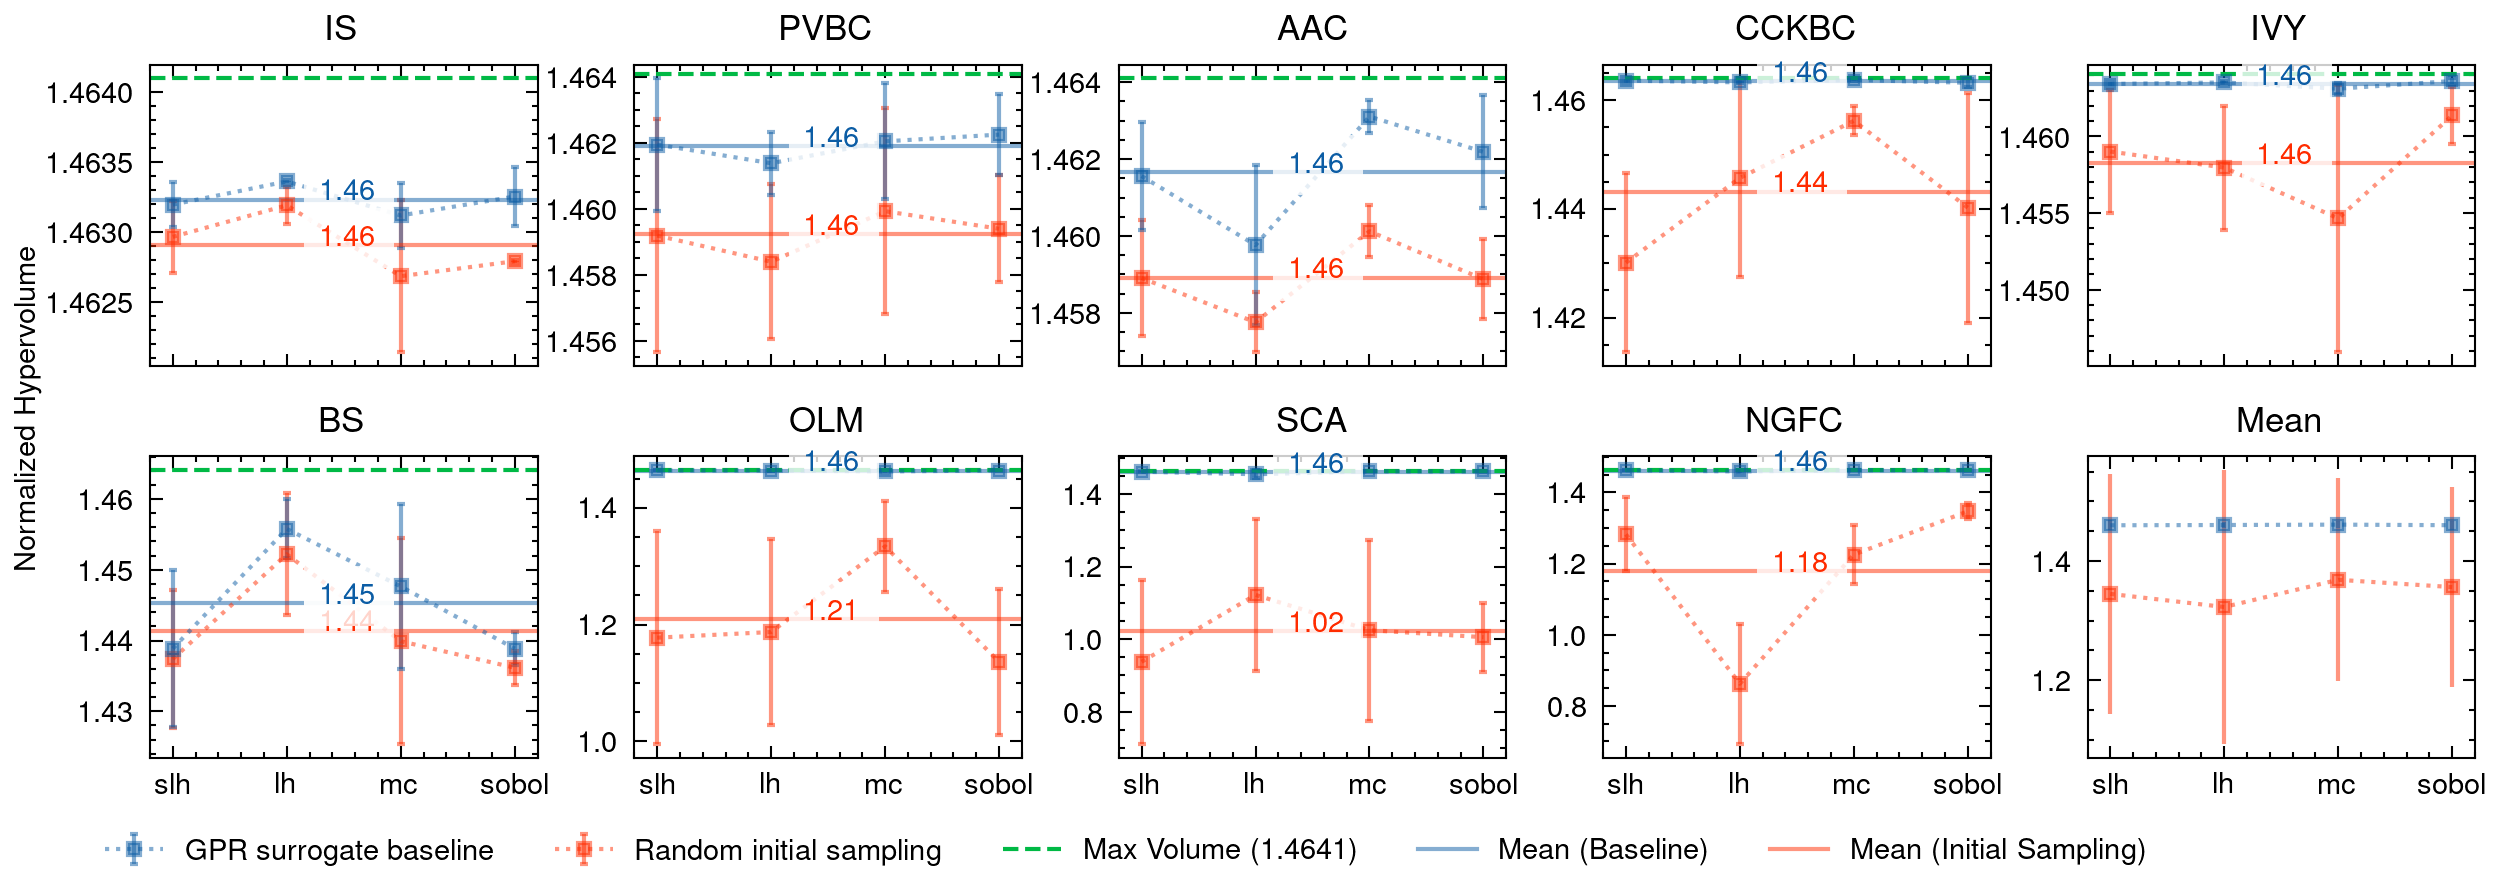

In [3]:
fig, axs = plt.subplots(2, 5, figsize=(10, 3), sharey=False, sharex=True)

c = {0: colors["red"], 1: colors["blue"]}

for ix, (ax, cell_type) in enumerate(
    zip(
        axs.flatten()[:-1],
        ["IS", "PVBC", "AAC", "CCKBC", "IVY", "BS", "OLM", "SCA", "NGFC"],
    )
):
    means_initial = []
    stds_initial = []
    means = []
    stds = []
    labels = []
    means_opt = []
    stds_opt = []
    labels_opt = []
    for name, hv in hvs[cell_type].items():
        if name.endswith("_initial"):
            means_initial.append(np.mean(hv))
            stds_initial.append(np.std(hv))
        elif name.endswith('_sopt'):
            means.append(np.mean(hv))
            stds.append(np.std(hv))
            labels.append(name.replace('_sopt', ''))
        else:
            # optimizers
            means_opt.append(np.mean(hv))
            stds_opt.append(np.std(hv))
            labels_opt.append(name)
    
    # ax.errorbar(
    #     labels_opt,
    #     means_opt,
    #     yerr=stds_opt,
    #     color='black',
    #     #fmt="s:",
    #     alpha=0.5,
    #    # label="GPR surrogate baseline",
    # )

    ax.errorbar(
        labels,
        means_initial,
        yerr=stds_initial,
        color=c[0],
        fmt="s:",
        capsize=1,
        alpha=0.5,
        label="Random initial sampling",
    )
    ax.errorbar(
        labels,
        means,
        yerr=stds,
        color=c[1],
        fmt="s:",
        alpha=0.5,
        capsize=1,
        label="GPR surrogate baseline",
    )

    for i, ms in enumerate([means_initial, means]):
        mean_value = np.mean(ms)
        ax.axhline(
            y=mean_value,
            # xmin=0.3,
            # xmax=1,
            xmin=0, xmax=3,
            color=c[i],
            linestyle="-",
            alpha=0.5,
            label="Mean (Initial Sampling)" if i == 0 else "Mean (Baseline)",
        )
        ax.text(
            1.3, #3.12, #len(labels) + 2,
            mean_value,
            f"{mean_value:.2f}",
            color=c[i],
            #verticalalignment="top",
            #horizontalalignment="center",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none") #if cell_type in ['OLM', 'SCA', 'NGFC', 'IVY', 'CCKBC'] else None,
        )
    ax.set_xlim(-0.2, 4)
    

    ax.axhline(
        y=1.1**4, color=colors["green"], linestyle="--", label=f"Max Volume ({1.1**4:.4f})"
    )
    # if ix < 3:
    #     ax.set_ylim(1.4, 1.1**4 * 1.05)
    # ax.legend()
    ax.set_title(cell_type)  # , y=0.7)

    # ax.set_xticklabels(labels, rotation=45, ha='right')

ax2 = axs[1][-1]
for i, ms in enumerate([means_initial, means]):
    mean_by_sampler = {
        sampler: np.mean(
            [
                models[(sampler + "_initial") if i == 0 else (sampler + '_sopt')]
                for models in hvs.values()
            ]
        )
        for sampler in labels
    }
    std_by_sampler = {
        sampler: np.std(
            [
                models[(sampler + "_initial") if i == 0 else (sampler + '_sopt')]
                for models in hvs.values()
            ]
        )
        for sampler in labels
    }
    ax2.errorbar(
        labels,
        [mean_by_sampler[l] for l in labels],
        yerr=[std_by_sampler[l] for l in labels],
        fmt="s:",
        color=c[i],
        alpha=0.5,
        label="Mean across cells",
    )
    
    ax.set_xlim(-0.2, 3.2)


ax2.set_title("Mean")  # , y=0.7)


# axs[0][0].set_ylabel("Normalized Hypervolume")
# axs[1][0].set_ylabel("Normalized Hypervolume")
fig.text(0.08, 0.5, "Normalized Hypervolume", va="center", rotation="vertical")

handles, ll = axs[0][0].get_legend_handles_labels()
fig.legend(
    reversed(handles), reversed(ll), ncol=len(ll), bbox_to_anchor=(0.8, 0.05)
)

plt.subplots_adjust(wspace=0.25, hspace=0.3)
plt.show()

In [14]:
stash("figure2/samplers", fig)

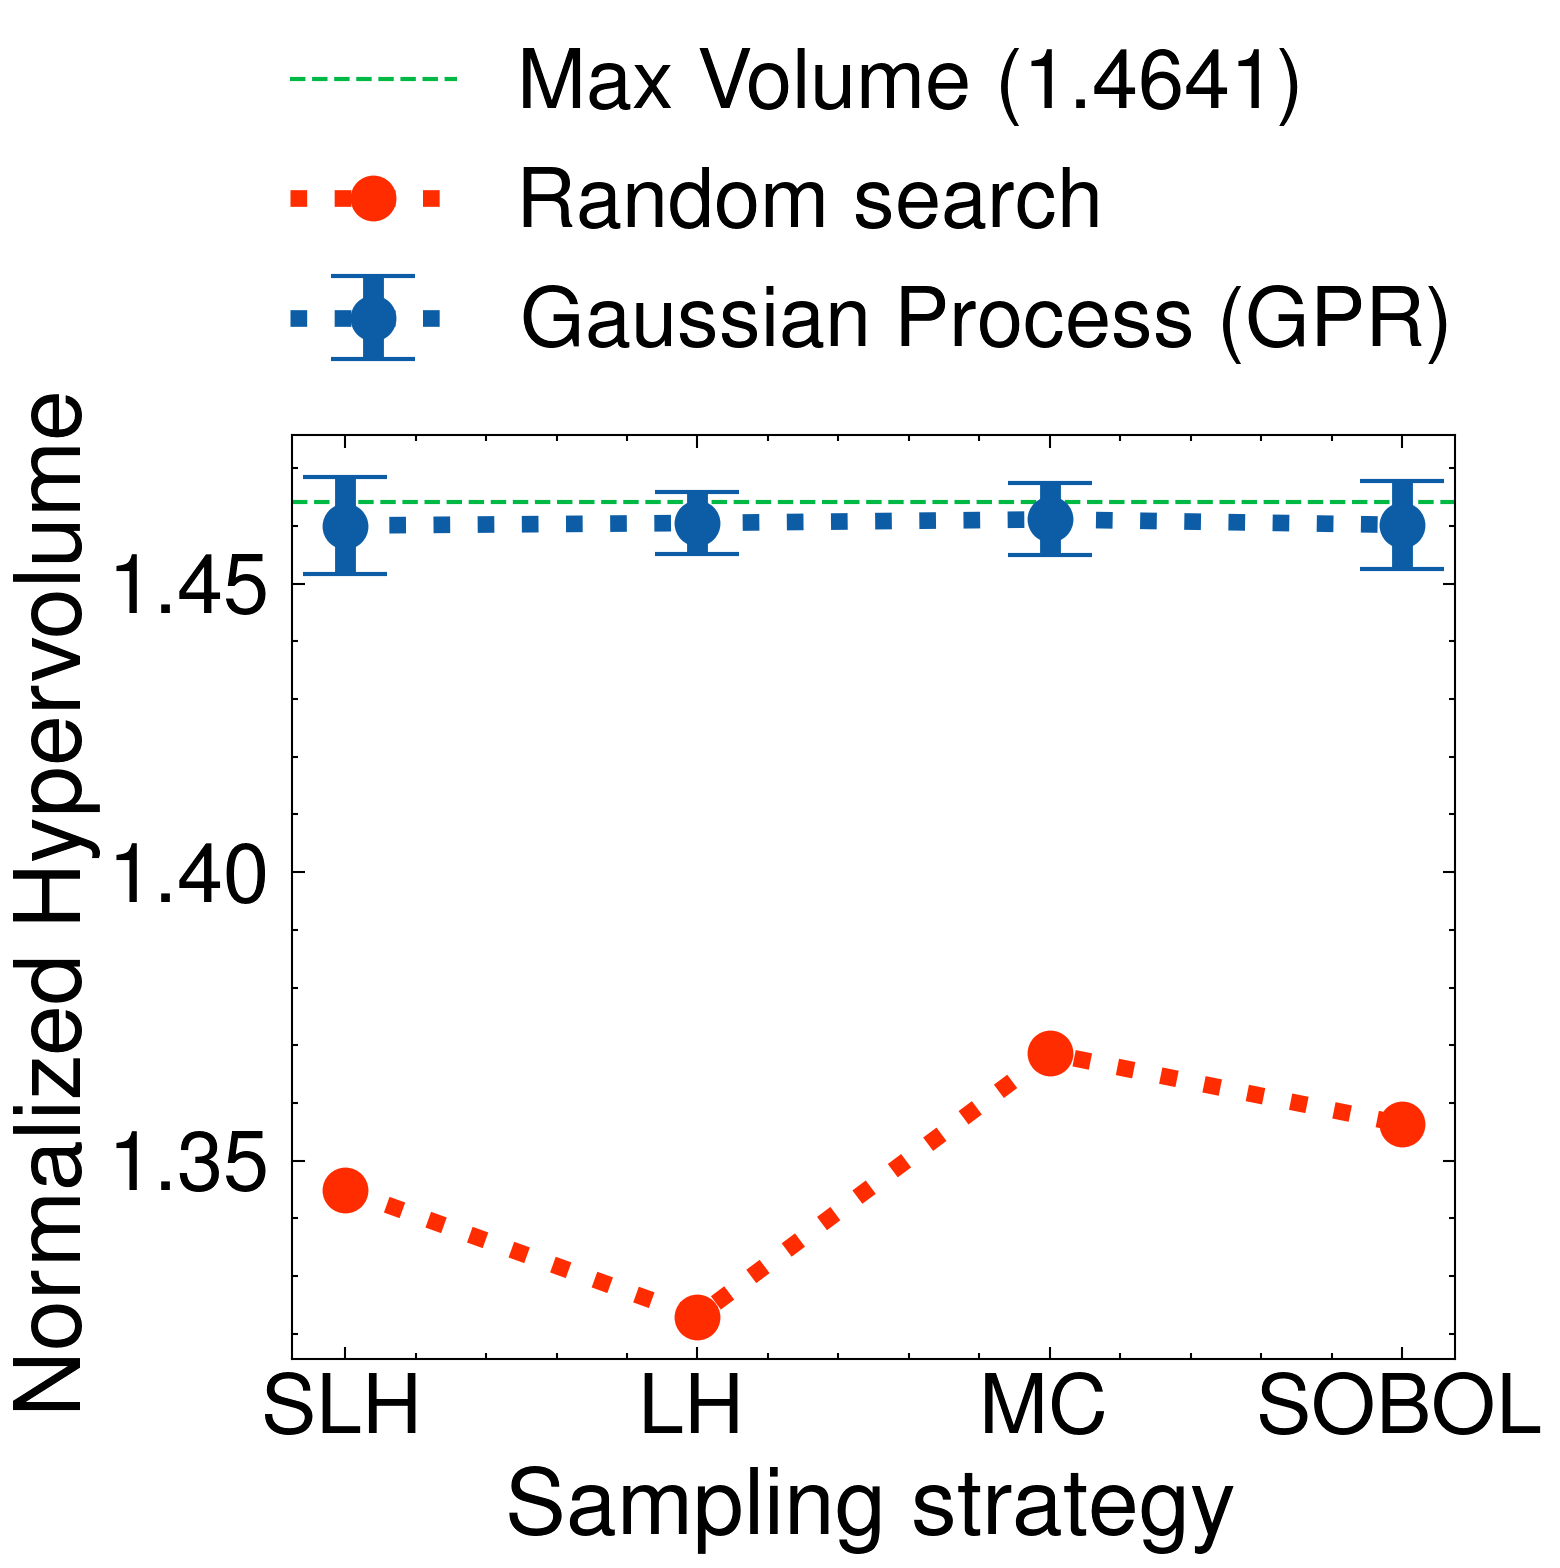

In [57]:
with rc_context():

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.axhline(
        y=1.1**4, color=colors["green"], linestyle="--", label=f"Max Volume ({1.1**4:.4f})"
    )

    for i, ms in enumerate([means_initial, means]):
        mean_by_sampler = {
            sampler: np.mean(
                [
                    models[(sampler + "_initial") if i == 0 else (sampler + '_sopt')]
                    for models in hvs.values()
                ]
            )
            for sampler in labels
        }
        std_by_sampler = {
            sampler: np.std(
                [
                    models[(sampler + "_initial") if i == 0 else (sampler + '_sopt')]
                    for models in hvs.values()
                ]
            )
            for sampler in labels
        }
        if i == 1:
            ax.errorbar(
                [l.upper() for l in labels],
                [mean_by_sampler[l] for l in labels],
                yerr=[std_by_sampler[l] for l in labels],
                fmt="o:",
                color=c[i],
                #alpha=0.5,
                linewidth=4,
                markersize=10,
                elinewidth=5,
                label="Gaussian Process (GPR)",
                capsize=10
            )
        else:
            ax.plot(
                [l.upper() for l in labels],
                [mean_by_sampler[l] for l in labels],
                color=c[i],
                marker='o',
                linestyle=':',
                linewidth=4,
                markersize=10,
                label="Random search"
            )

        #handles, ll = ax.get_legend_handles_labels()
        plt.legend(
            #reversed(handles), reversed(ll),# ncol=len(ll), 
            bbox_to_anchor=(1.065, 1.5)
        )

        ax.set_xlabel("Sampling strategy")
        ax.set_ylabel("Normalized Hypervolume")

In [58]:
stash("figure2/sampling-mean-baseline", fig)

## Surrogate accuracy

In [ ]:
from models.metrics import compute_metric

metric_names = ['nrmse', 'mape', 'r2', 'spearman']

prediction_metrics = {}
timing_metrics = {}

for model in get('interface._ca1_inference').models():
    data = load_file(f'./figures/data/figure2-inference/{model}.p')

    population, model = model.split('-', 1)

    prediction_metrics.setdefault(population, {})
    timing_metrics.setdefault(population, {})

    prediction_metrics[population][model] = {}
    timing_metrics[population][model] = {
        'cv': [], 'fit': [], 'predict': []
    }

    for epoch in data:
        for metric_name in metric_names:
            for t in ['train', 'test']:
                prediction_metrics[population][model].setdefault(metric_name + '_' + t, [])

                y_true = epoch['y_' + t]
                y_pred = epoch['y_pred_' + t]

                if model.endswith('-c+o'):
                    y_pred = y_pred['objectives']

                prediction_metrics[population][model][metric_name+ '_' + t].append(
                    float(compute_metric(metric_name, y_true, y_pred))
                )

                timing_metrics[population][model]['cv'].append(
                    epoch["t_autoepoch"]
                )
                timing_metrics[population][model]['fit'].append(
                   epoch["t_autofit"]
                )
                timing_metrics[population][model]['predict'].append(
                   epoch['t_y_pred_train']
                )
                print(epoch["t_autofit"], model)
    break



In [5]:
stash('figure2-prediction_metrics', prediction_metrics)
stash('figure2-timing_metrics', timing_metrics)

In [2]:
prediction_metrics = restore('figure2-prediction_metrics')
timing_metrics = restore('figure2-timing_metrics')
metric_names = ['nrmse', 'mape', 'r2', 'spearman']

In [19]:
for p,q in timing_metrics.items():
    print(p, np.max(timing_metrics[p]['fttransformer-c+o']['fit']))

SCA 146.2499213218689
IVY 173.93055152893066
PVBC 194.3333911895752
CCKBC 182.2802016735077
AAC 208.78146767616272
BS 191.7682762145996
OLM 233.9483940601349
NGFC 166.55434489250183
IS 194.85064792633057


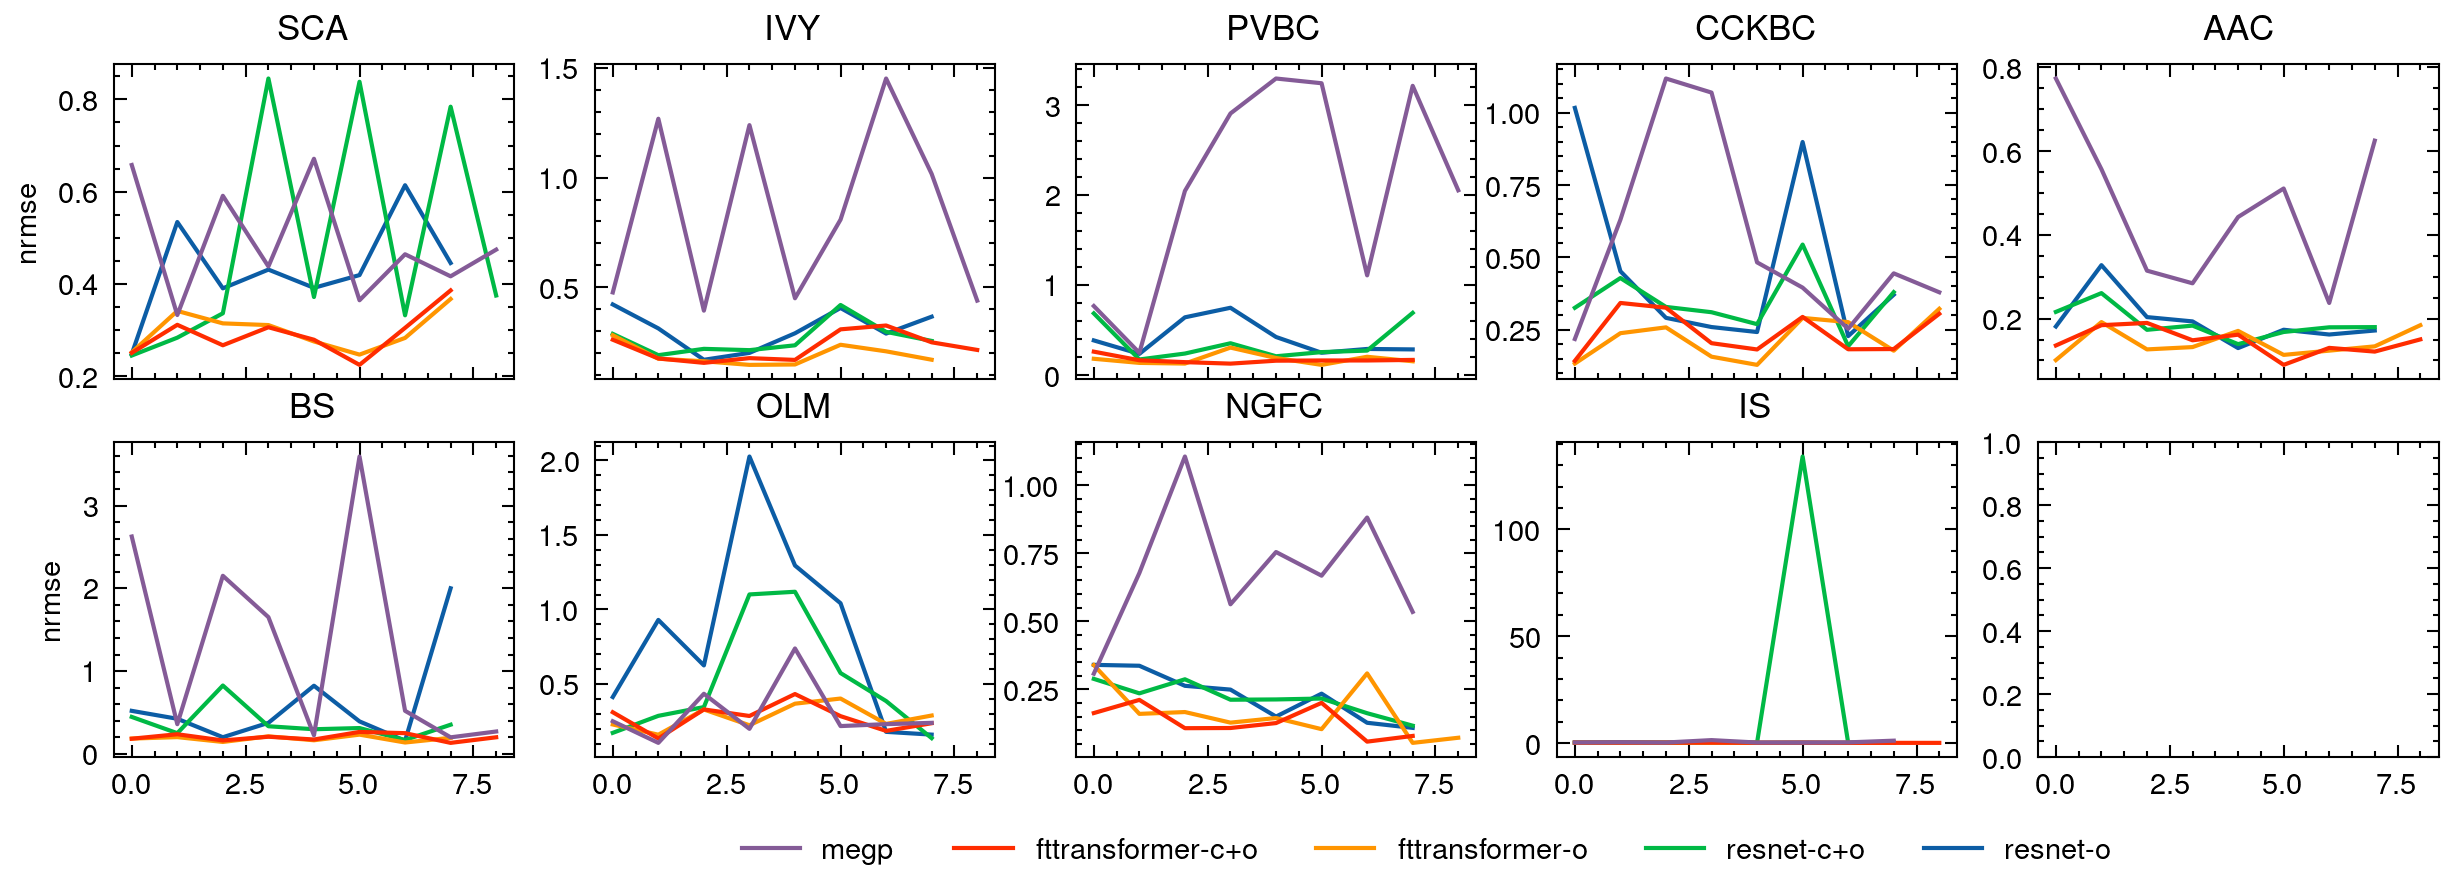

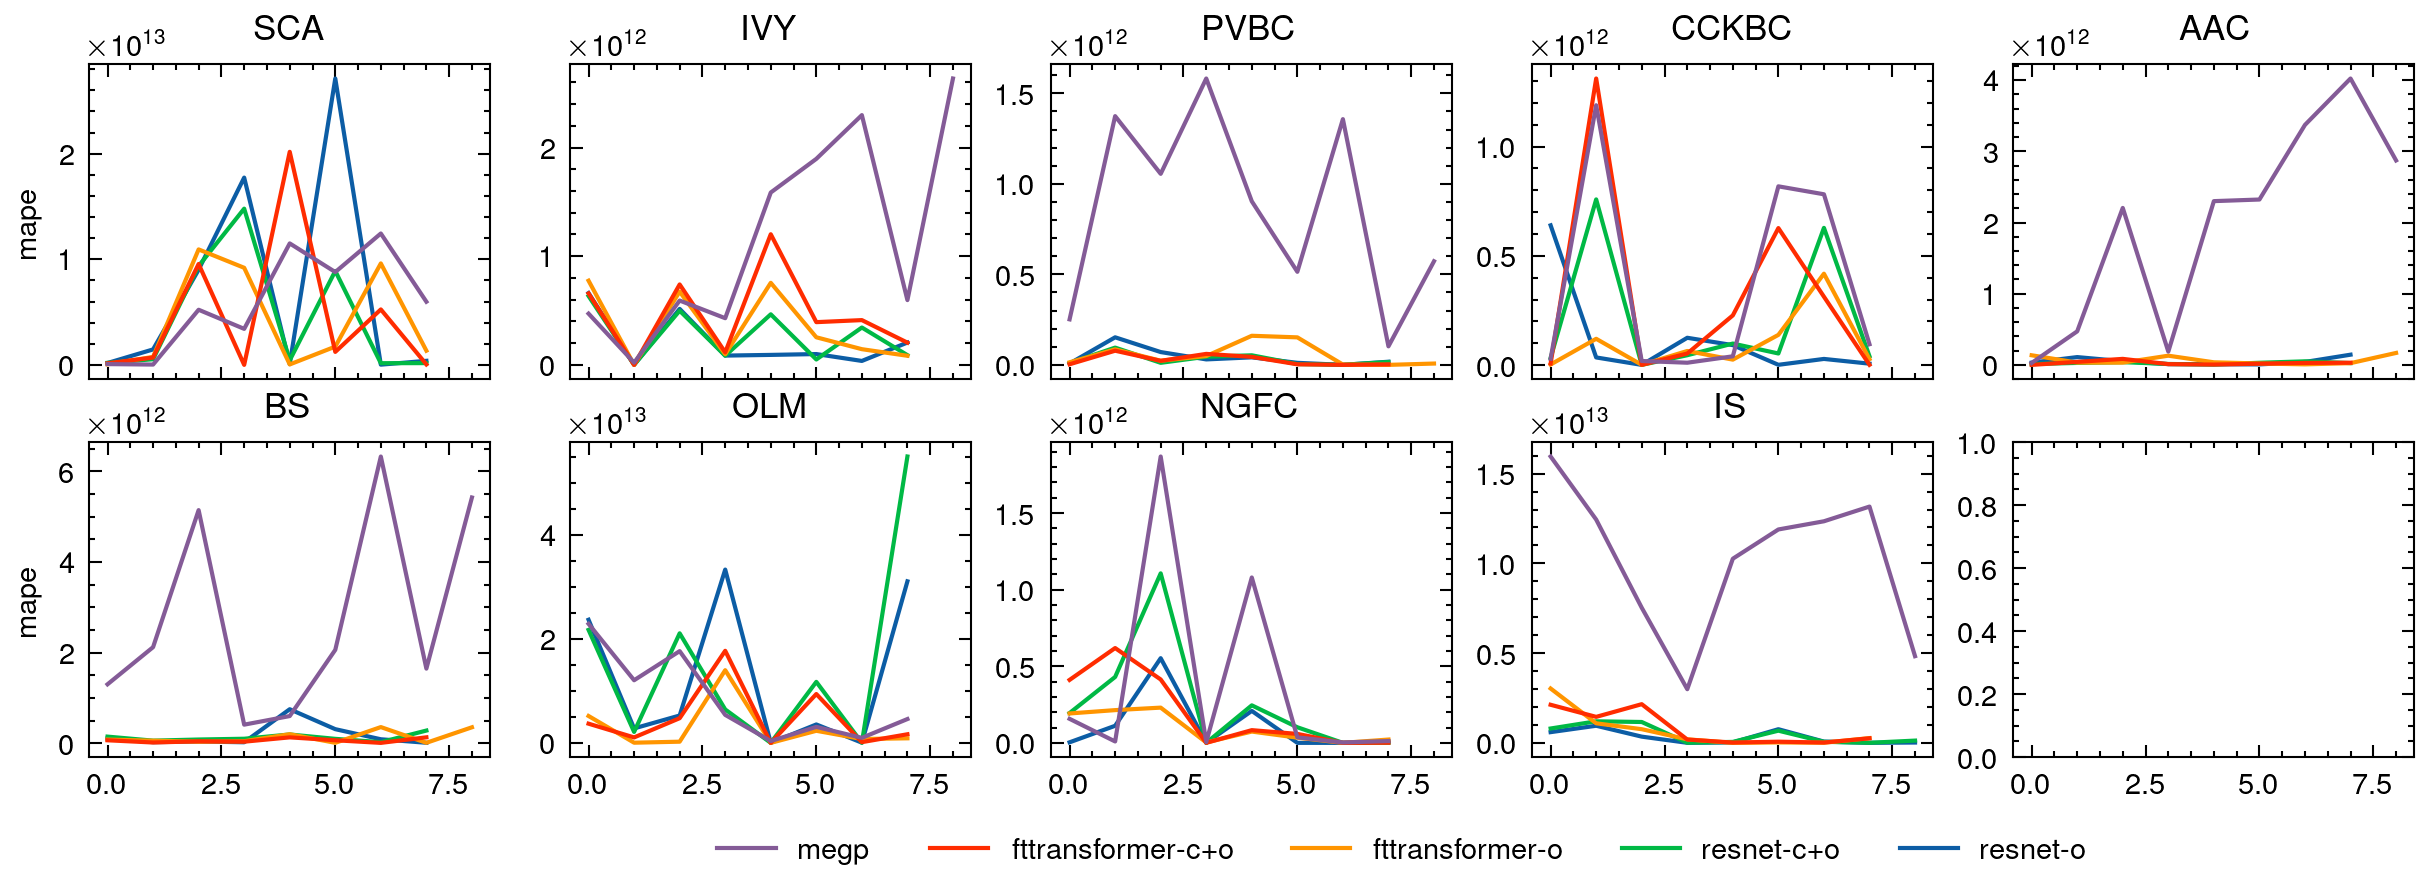

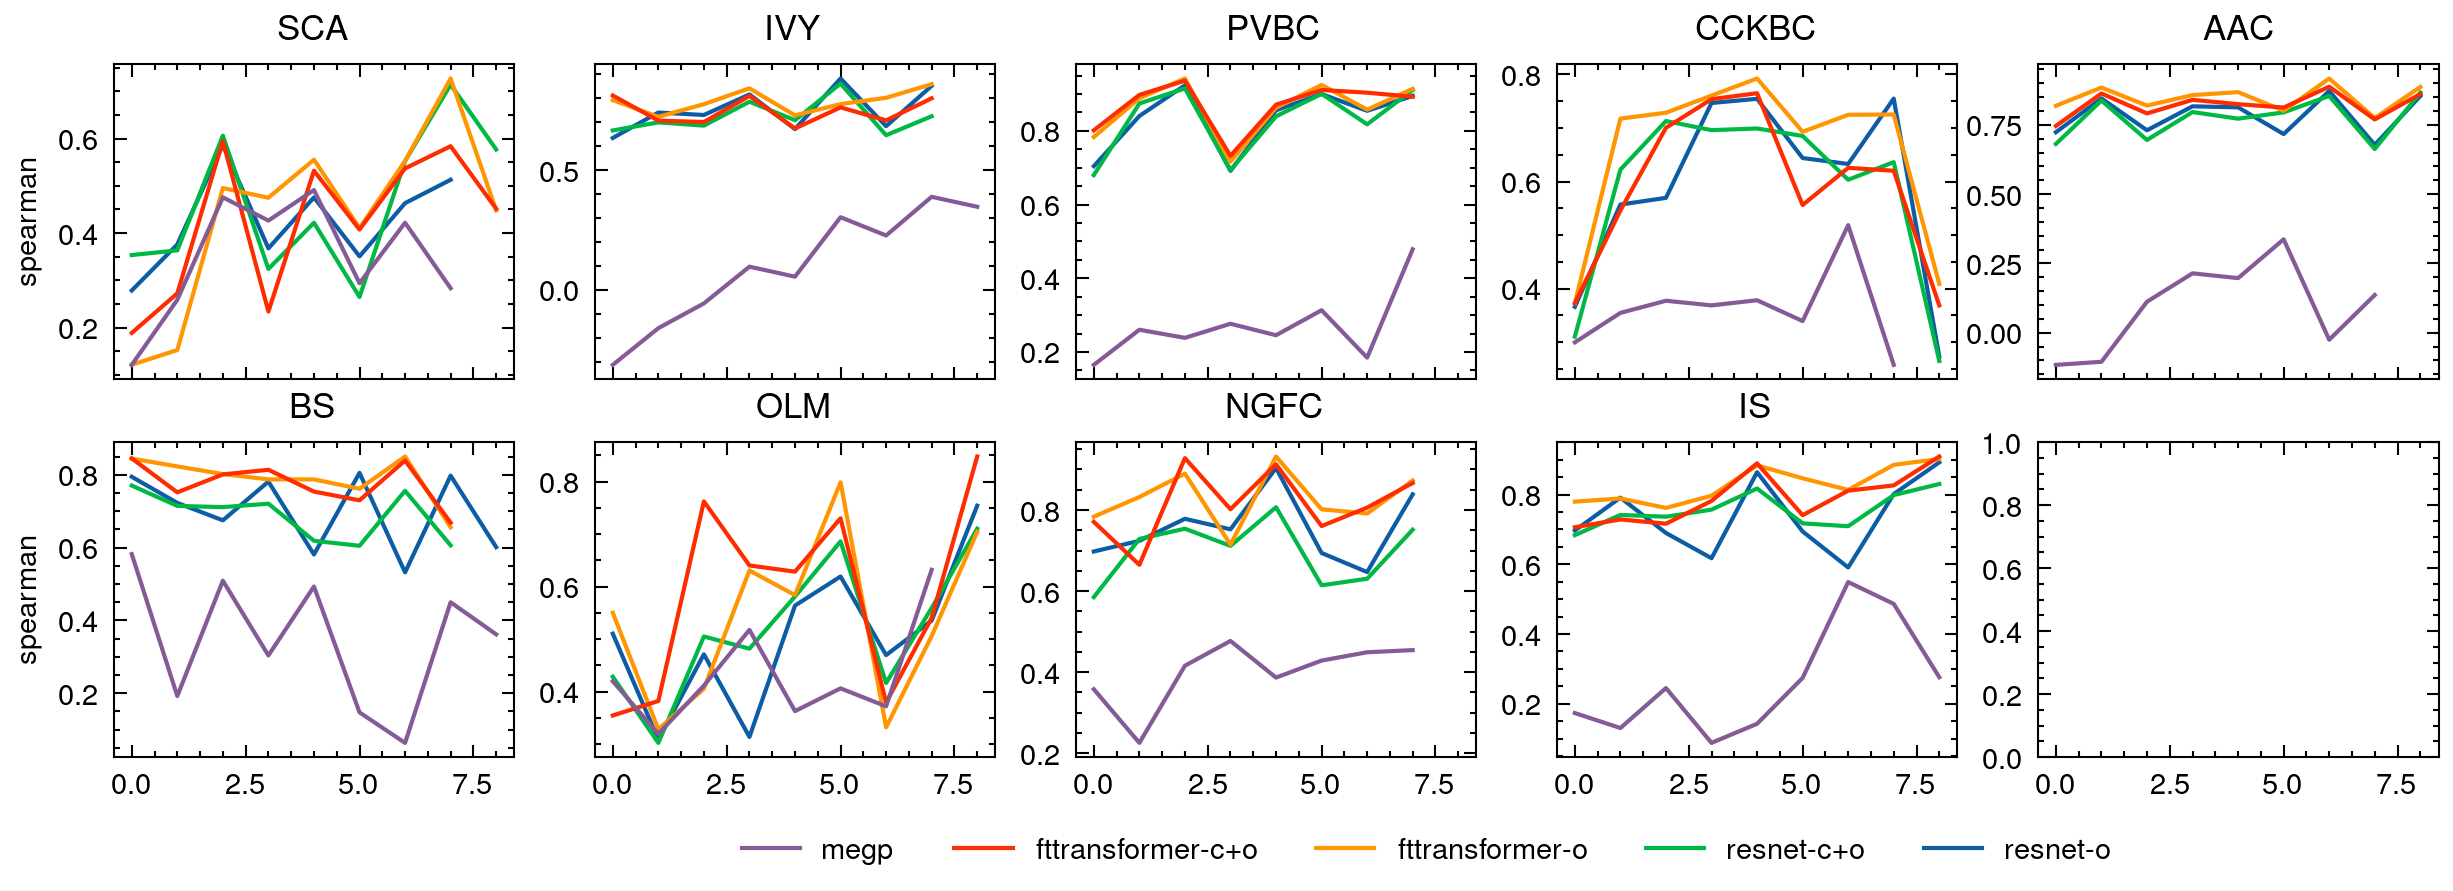

In [3]:
prediction_summary = {}

for metric_name in metric_names:
    if metric_name == 'r2':
        continue

    fig, axs = plt.subplots(2, 5, figsize=(10, 3), sharey=False, sharex=True)

    for ix, (cell_type, d) in enumerate(
        prediction_metrics.items()
    ):
        ax = axs.flatten()[ix]
        ax.set_title(cell_type)  # , y=0.7)

        for model, m in d.items():
            y = m[metric_name + '_test']

            # z-score filter outliers
            y_arr = np.array(y)
            z_scores = (y_arr - np.nanmean(y_arr)) / (np.nanstd(y_arr) + 1e-8)
            outlier_mask = np.abs(z_scores) > 2
            y_arr[outlier_mask] = np.nan
            y = y_arr.tolist()

            prediction_summary.setdefault(metric_name, {})
            prediction_summary[metric_name].setdefault(model, [])

            y = np.array(y)
            y = y[~np.isnan(y)]
            prediction_summary[metric_name][model] += y.tolist()

            ax.plot(np.arange(len(y)), y, label=model)

    axs[0][0].set_ylabel(metric_name)
    axs[1][0].set_ylabel(metric_name)

    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(
        reversed(handles), reversed(labels), ncol=len(labels), bbox_to_anchor=(0.8, 0.05)
    )
    
    #plt.subplots_adjust(wspace=0.25, hspace=0.3)
    plt.show()

    

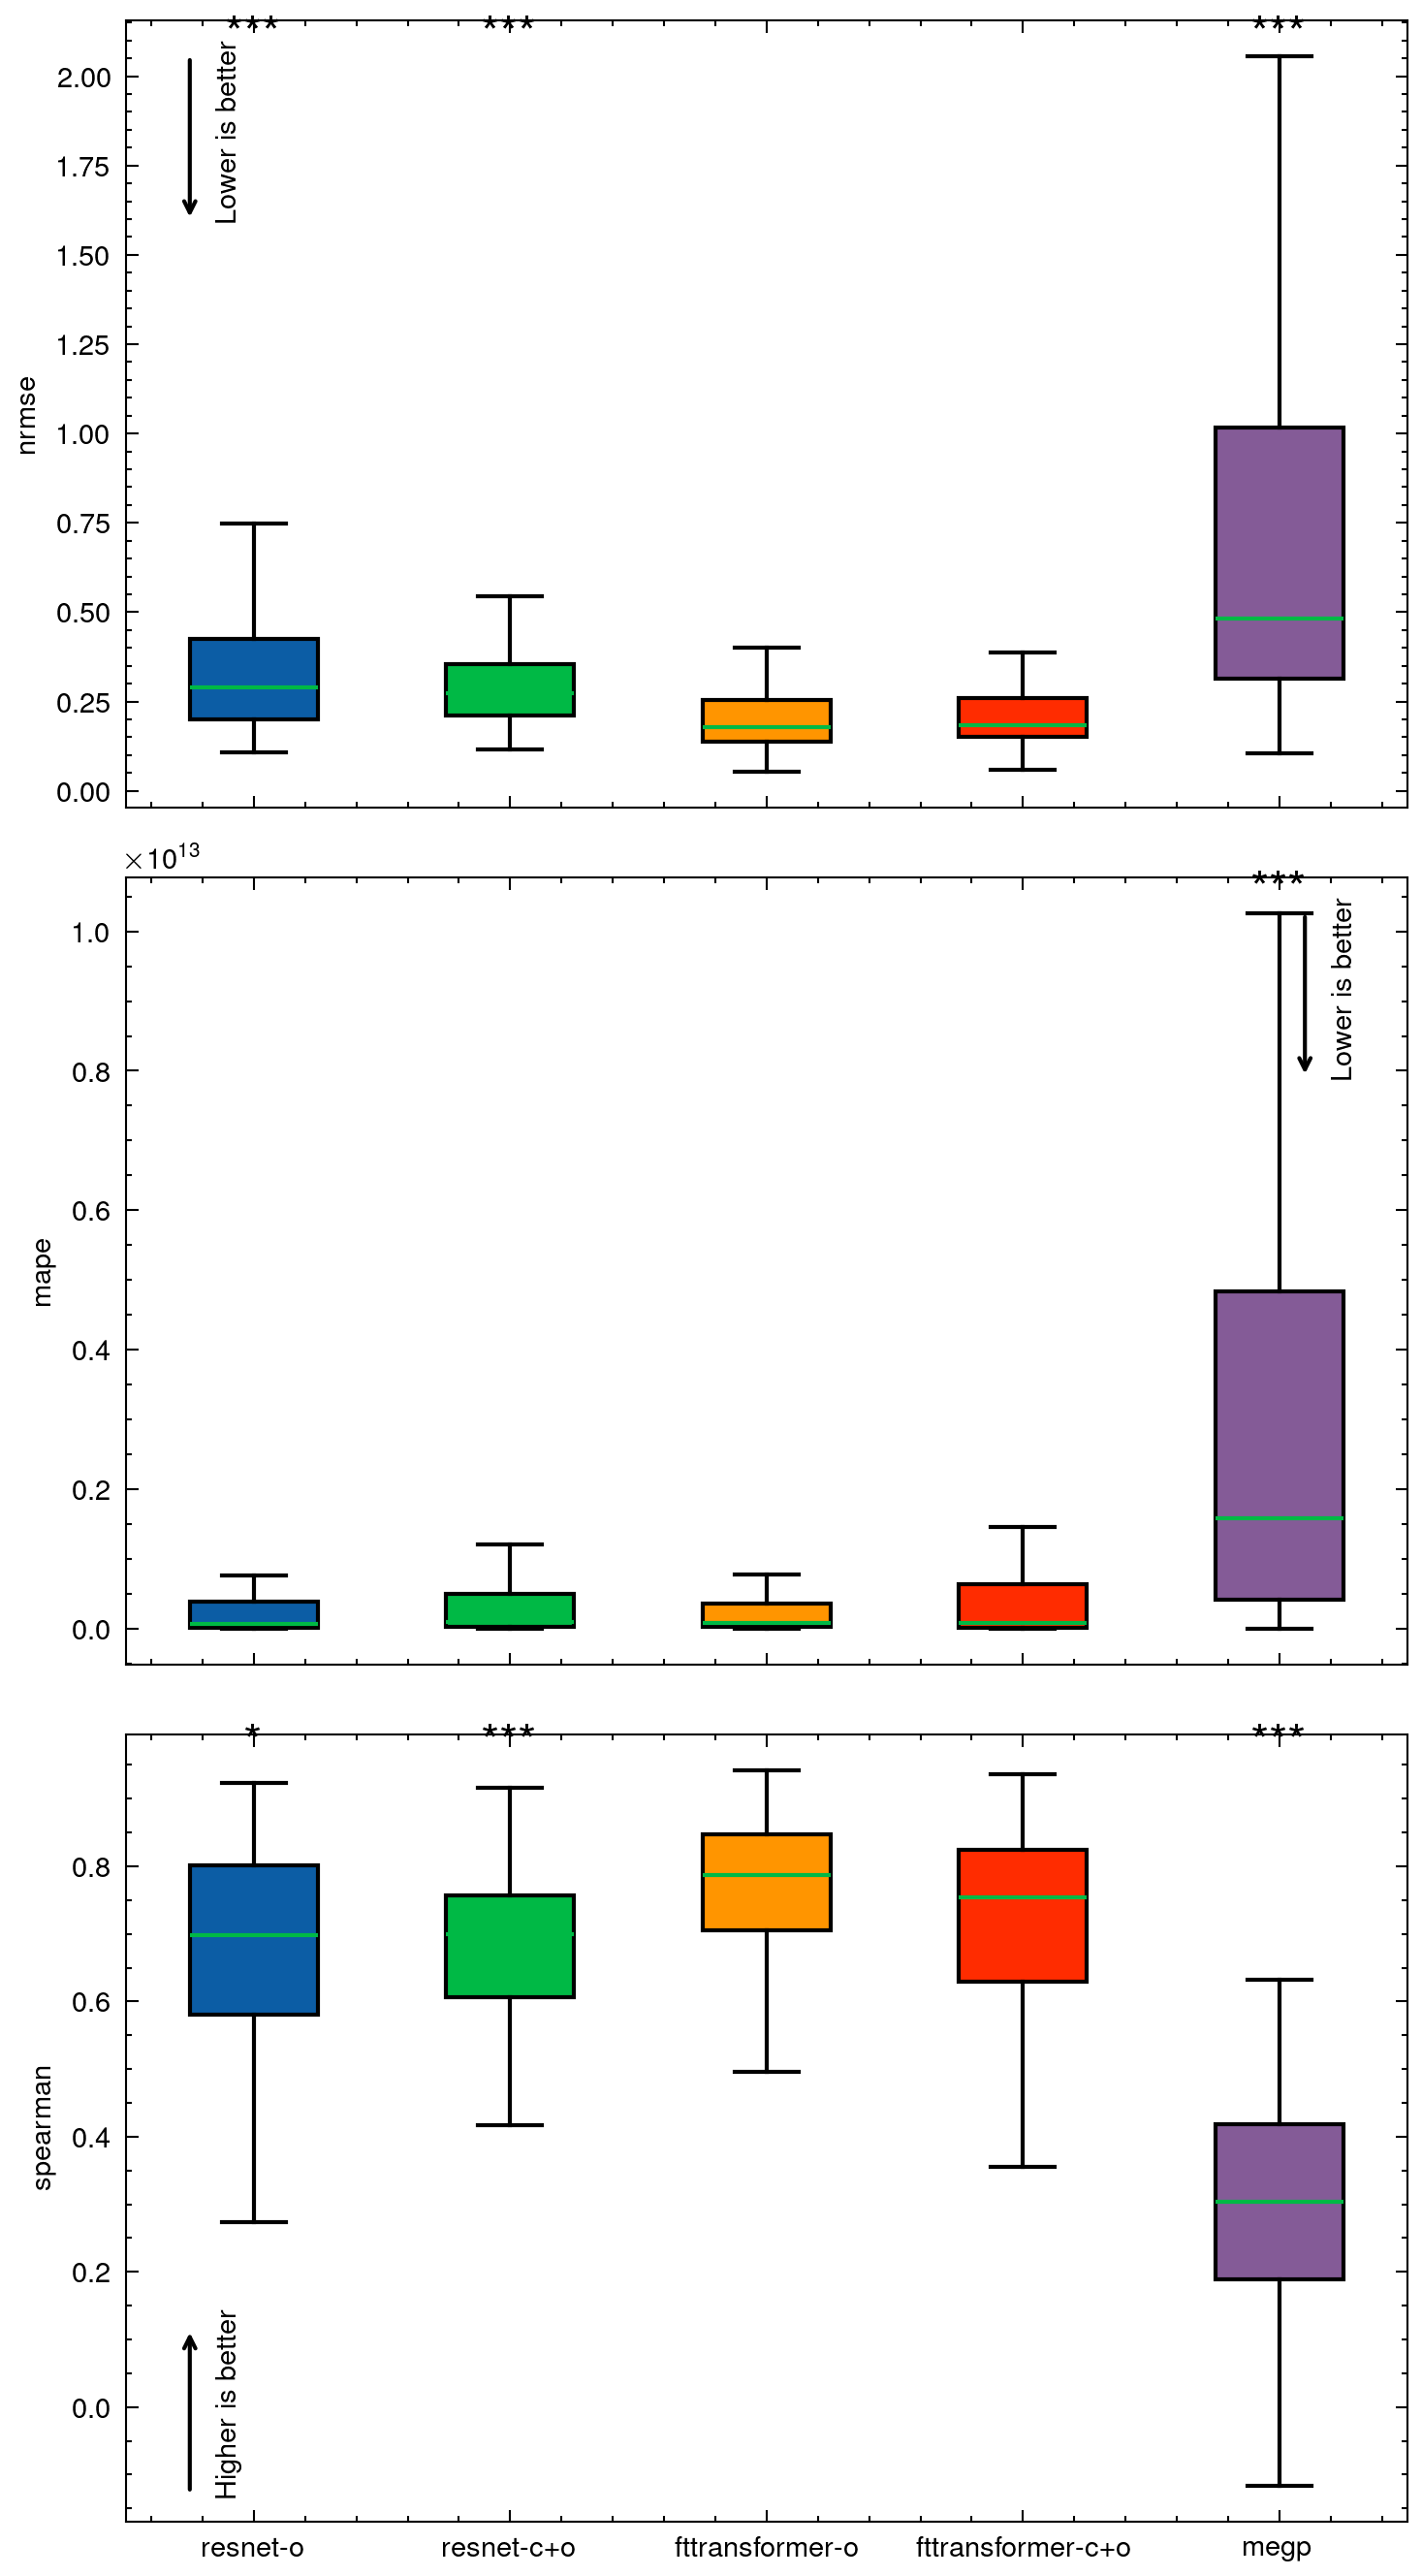

In [12]:
from scipy import stats

fig, axs = plt.subplots(len(prediction_summary), 1, figsize=(5, 3* len(prediction_summary)), sharex=True)

def get_significance_stars(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

significance_results = {}
for metric_name, model_dict in prediction_summary.items():
    significance_results[metric_name] = {}
    models = list(model_dict.keys())
    if metric_name in ['nrmse', 'mape']:
        best_model = min(models, key=lambda m: np.mean(model_dict[m]))
    else:
        # spearman
        best_model = max(models, key=lambda m: np.mean(model_dict[m]))
    
    for model in models:
        if model != best_model:
            _, p_value = stats.mannwhitneyu(
                model_dict[best_model], 
                model_dict[model], 
                alternative='two-sided'
            )
            significance_results[metric_name][model] = get_significance_stars(p_value)
        else:
            significance_results[metric_name][model] = ''





for i, (metric_name, model_dict) in enumerate(prediction_summary.items()):
    ax = axs[i]
    data = [model_dict[model] for model in model_dict]
    bplot = ax.boxplot(data, tick_labels=list(model_dict.keys()), patch_artist=True, showfliers=False)
    #ax.set_title(metric)
    ax.set_ylabel(metric_name)

    for patch, color in zip(bplot['boxes'], icolors):
        patch.set_facecolor(color)

    if metric_name == 'spearman':
        lx = 0.05
        ly = 0.25
        ax.annotate(
            "",
            xy=(lx, ly),
            xytext=(lx, ly - 0.22),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="black"),
            annotation_clip=False,
        )
        ax.text(
            lx + 0.03,
            ly - 0.1,
            "Higher is better",
            rotation=90,
            va="center",
            ha="center",
            transform=ax.transAxes,
        )

    else:

        lx = 0.92 if metric_name == 'mape' else 0.05
        ly = 0.96 
        ax.annotate(
            "",
            xy=(lx, ly),
            xytext=(lx, ly - 0.22),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="<-", color="black"),
            annotation_clip=False,
        )
        ax.text(
            lx + 0.03,
            ly - 0.1,
            "Lower is better",
            rotation=90,
            va="center",
            ha="center",
            transform=ax.transAxes,
        )



ax.set_xticks(np.arange(1, len(model_dict) + 1))
#ax.set_xticklabels(list(model_dict.keys()), rotation=45, ha='right')


for i, (metric_name, model_dict) in enumerate(prediction_summary.items()):
    ax = axs[i]
    
    for j, model in enumerate(model_dict.keys(), 1):
        if model in significance_results[metric_name] and significance_results[metric_name][model]:
            y_max = ax.get_ylim()[1]
            y_pos = y_max * 0.95
            ax.text(j, y_pos, significance_results[metric_name][model], 
                   ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
stash('figure2/prediction-metrics', fig)

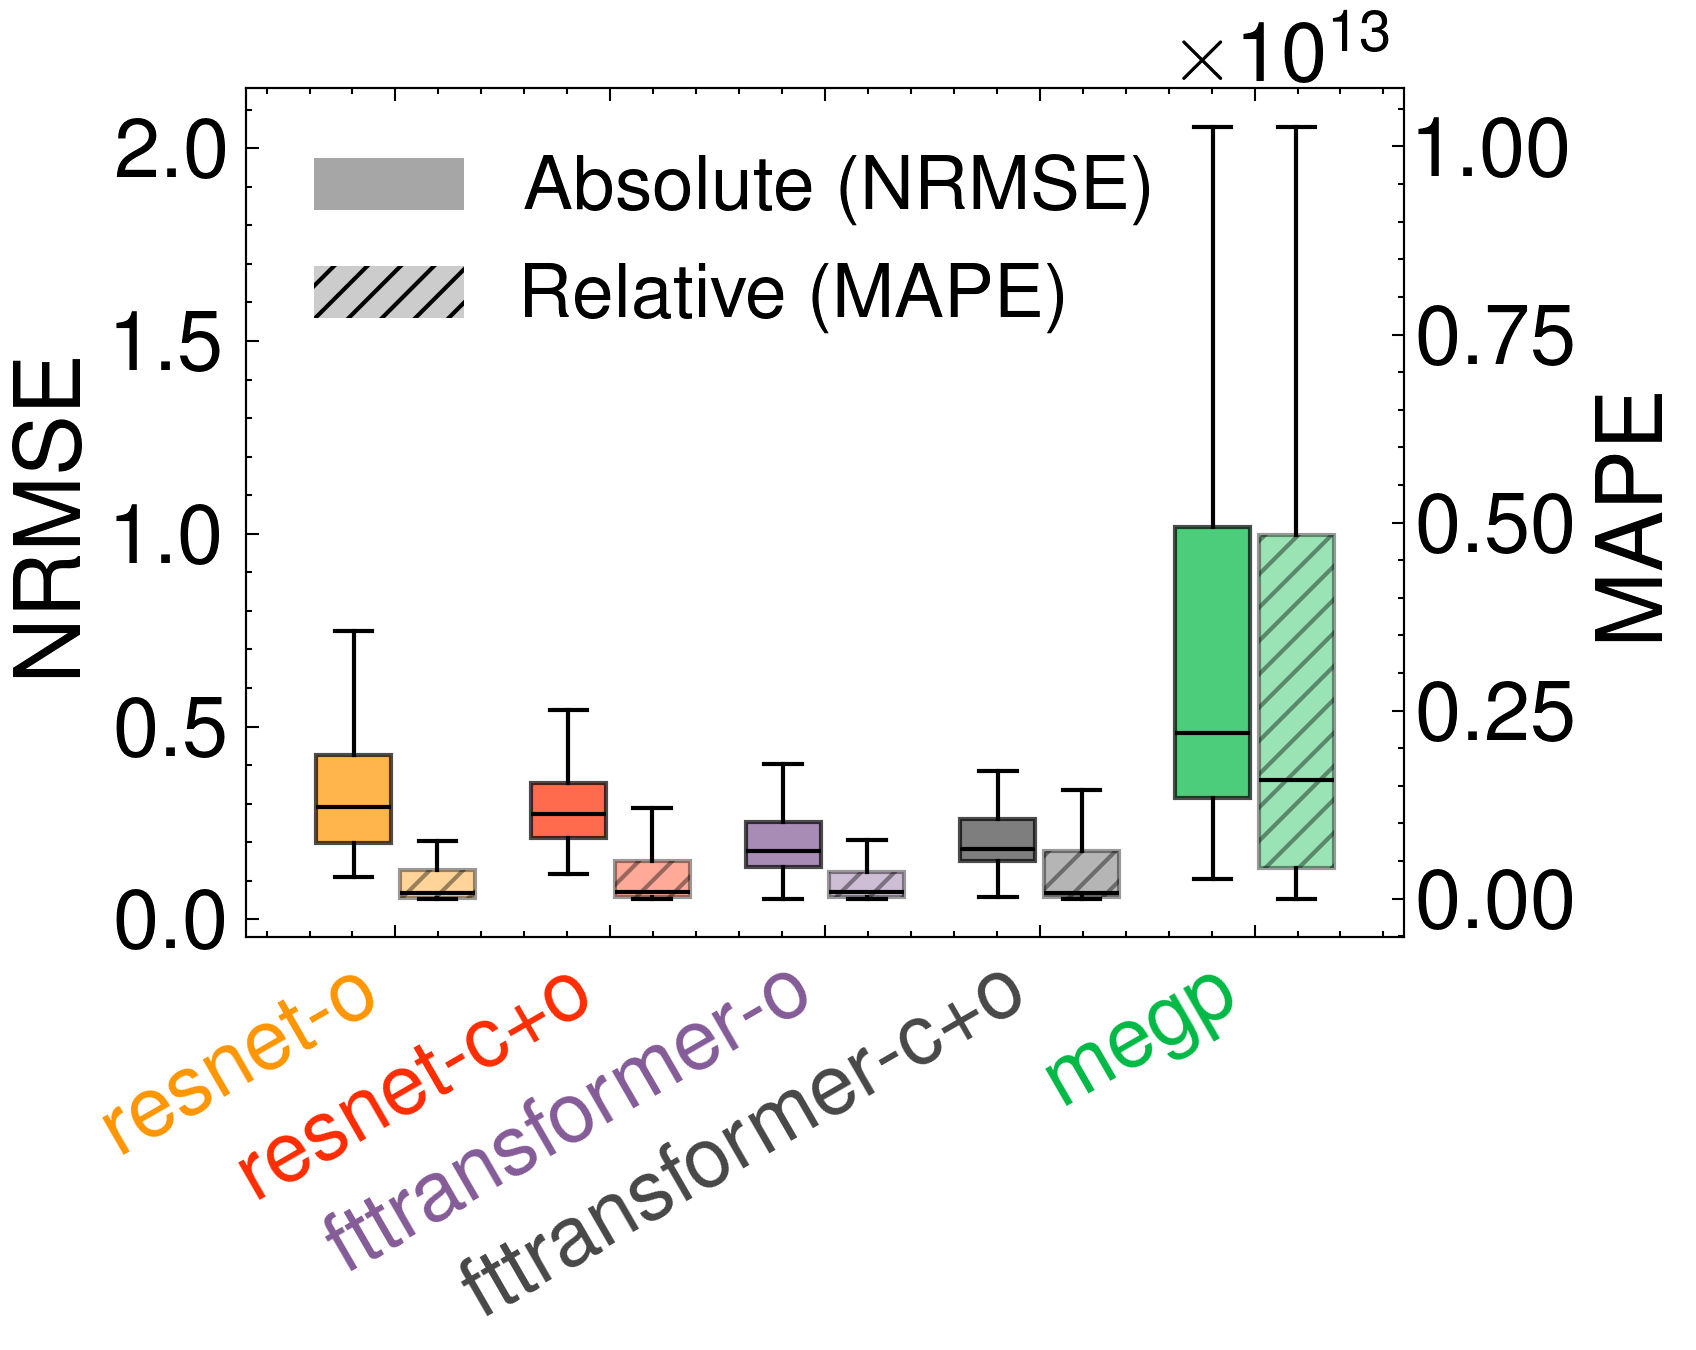

In [65]:
from matplotlib.patches import Patch

with rc_context():

    fig, ax = plt.subplots(figsize=(6, 5))

    model_dict_nrmse = prediction_summary['nrmse']
    model_dict_mape = prediction_summary['mape']

    models = list(model_dict_nrmse.keys())
    x = np.arange(len(models))
    width = 0.35
    padding = 0.02

    data_nrmse = [model_dict_nrmse[model] for model in models]
    data_mape = [model_dict_mape[model] for model in models]

    

    bplot1 = ax.boxplot(
        data_nrmse, 
        positions=x - width/2 - padding,
        widths=width,
        patch_artist=True, 
        showfliers=False,
        medianprops=dict(color='black')
    )

    ocolor = icolors[2:6] + [icolors[1]]

    for patch, color in zip(bplot1['boxes'], ocolor):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel('NRMSE', color='black')
    ax.tick_params(axis='y', labelcolor='black')

    ax2 = ax.twinx()
    bplot2 = ax2.boxplot(
        data_mape,
        positions=x + width/2 + padding,
        widths=width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black')
    )

    for patch, color in zip(bplot2['boxes'], ocolor):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    ax2.set_ylabel('MAPE', color='black')
    ax2.tick_params(axis='y', labelcolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels([m for m in models], rotation=30, ha='right')
    for tick_label, color in zip(ax.get_xticklabels(), ocolor):
        tick_label.set_color(color)


    for patch in bplot2['boxes']:
        patch.set_hatch('///')


    legend_elements = [
        # Patch(facecolor=icolors[i % len(icolors)], label=model, alpha=0.7) 
        # for i, model in enumerate(models)
    ]
    legend_elements.extend([
        Patch(facecolor='gray', label='Absolute (NRMSE)', alpha=0.7),
        Patch(facecolor='gray', label='Relative (MAPE)', alpha=0.4, hatch='///')
    ])
    ax.legend(handles=legend_elements, loc='upper left', fontsize=18)

    #ax.set_xticks(np.arange(1, len(model_dict) + 1))
    #ax.set_xticklabels(list(model_dict.keys()), rotation=45, ha='right')


    # for j, model in enumerate(models):
    #     if model in significance_results['nrmse'] and significance_results['nrmse'][model]:
    #         y_max = ax.get_ylim()[1]
    #         y_pos = y_max * 1.1
    #         ax.text(j - width/2 - padding, y_pos, significance_results['nrmse'][model], 
    #                ha='center', va='bottom', fontsize=20, fontweight='bold')

    # for j, model in enumerate(models):
    #     if model in significance_results['mape'] and significance_results['mape'][model]:
    #         y_max = ax2.get_ylim()[1]
    #         y_pos = y_max * 1.1
    #         ax2.text(j + width/2 + padding, y_pos, significance_results['mape'][model], 
    #                ha='center', va='bottom', fontsize=20, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [66]:
stash('figure2/prediction-mape-nrmse', fig)

## Timing

In [67]:
tt = {}
from uncertainties import ufloat

for p, d in timing_metrics.items():
    for model, dd in d.items():
        tt.setdefault(model, {})
        for v, ddd in dd.items():
            tt[model].setdefault(v, [])
            tt[model][v] += ddd
        for k in [kk for kk in tt[model].keys() if 'u' not in kk]:
            tt[model][f"{k}_mean"] = np.mean(tt[model][k])
            tt[model][f"{k}_std"] = np.std(tt[model][k])
            tt[model][f"{k}_u"] = ufloat(tt[model][f"{k}_mean"], tt[model][f"{k}_std"])

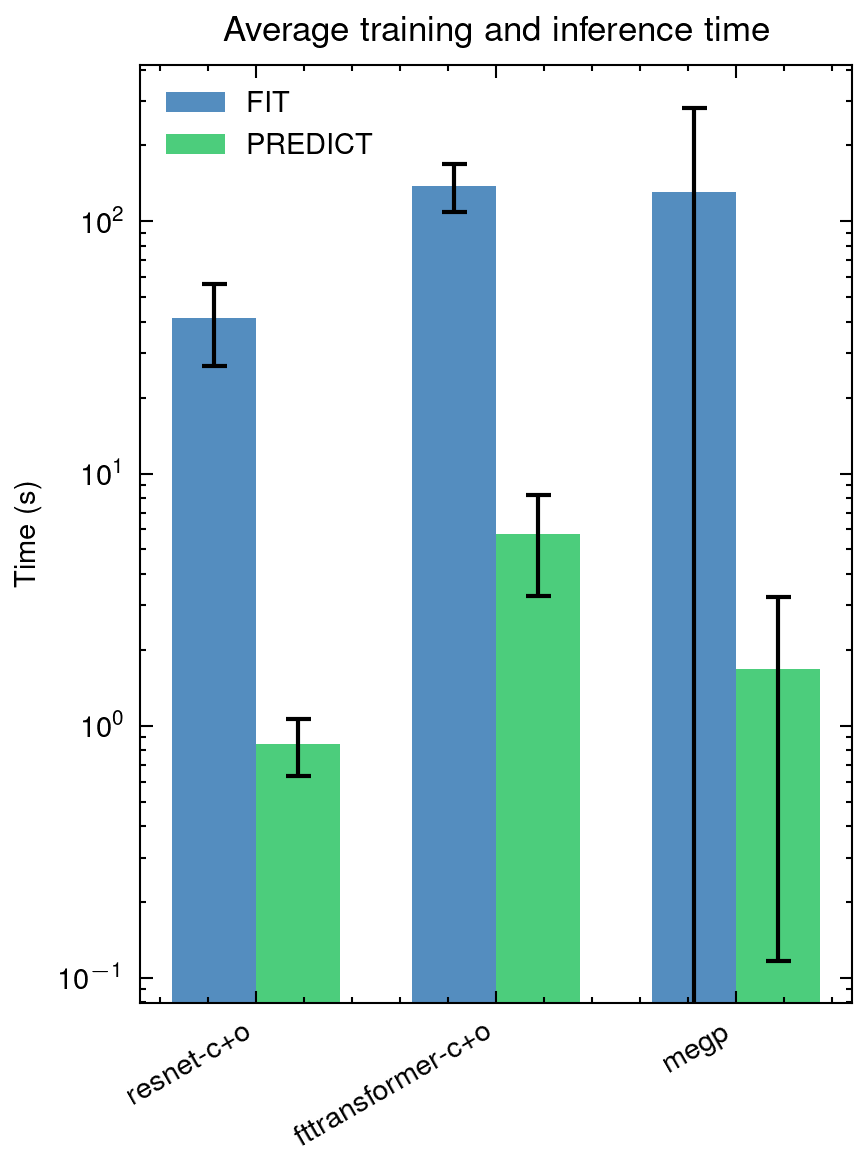

In [68]:
import numpy as np

models = ['resnet-c+o', 'fttransformer-c+o', 'megp']
modes = ['fit', 'predict']

import matplotlib.pyplot as plt


bar_width = 0.35
x = np.arange(len(models))

means = {mode: [tt[model][f"{mode}_mean"] for model in models] for mode in modes}
stds = {mode: [tt[model][f"{mode}_std"] for model in models] for mode in modes}

fig, ax = plt.subplots(figsize=(3, 4))

for i, mode in enumerate(modes):
    ax.bar(
        x + i * bar_width,
        means[mode],
        bar_width,
        yerr=stds[mode],
        label=mode.upper(),
        capsize=3,
        alpha=0.7,
    )

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylabel("Time (s)")
ax.set_yscale('log')
ax.set_title("Average training and inference time")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
stash('figure2/time-comparison', fig)

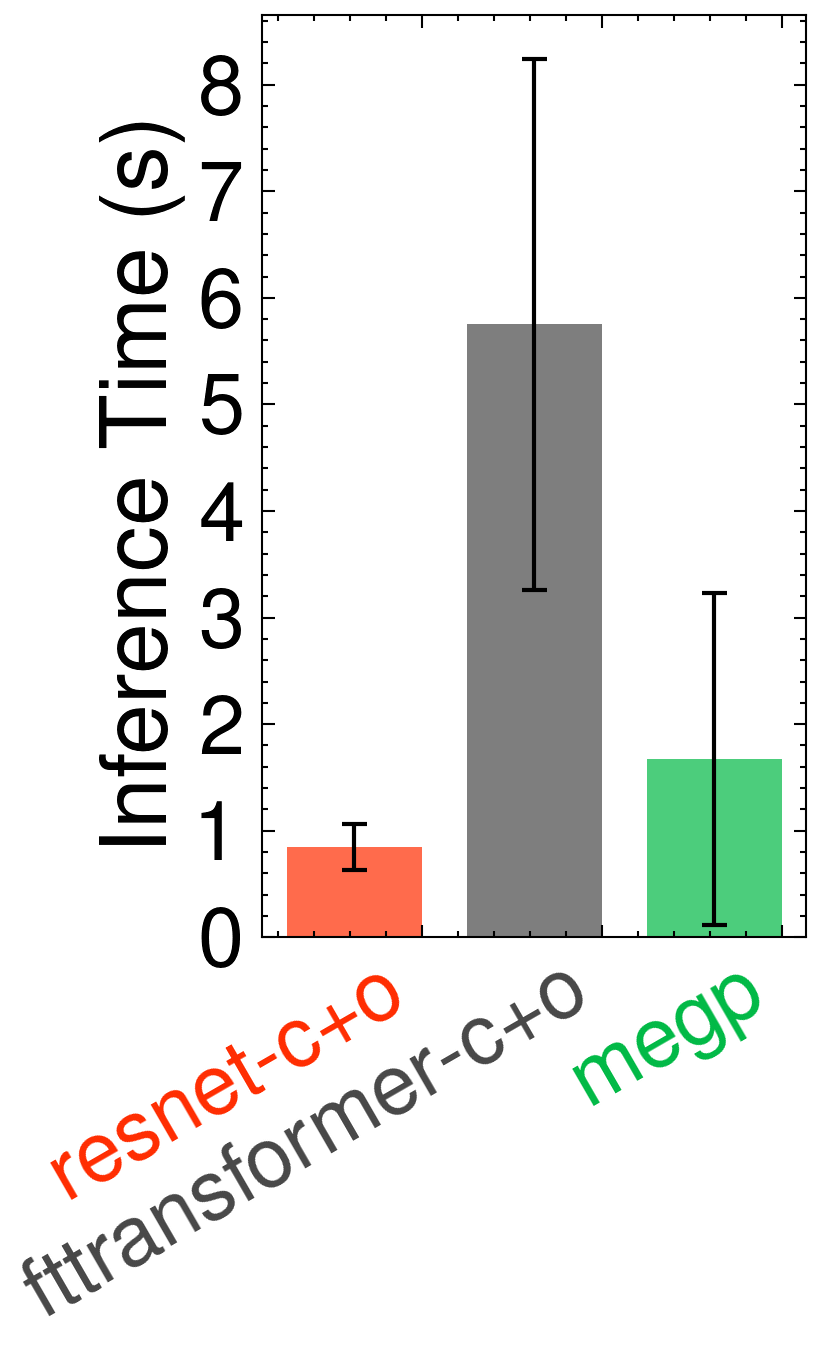

In [85]:
models = ['resnet-c+o', 'fttransformer-c+o', 'megp']
modes = ['predict']

with rc_context():

    bar_width = 0.75
    x = np.arange(len(models))

    means = {mode: [tt[model][f"{mode}_mean"] for model in models] for mode in modes}
    stds = {mode: [tt[model][f"{mode}_std"] for model in models] for mode in modes}

    fig, ax = plt.subplots(figsize=(3, 5))

    model_colors = [mcolors["c+o-resnet"], mcolors["c+o-fttransformer"], mcolors["megp"]]

    for i, mode in enumerate(modes):
        ax.bar(
            x,
            means[mode],
            bar_width,
            yerr=stds[mode],
            label=mode.upper(),
            capsize=3,
            alpha=0.7,
            color=model_colors
        )

    for tick_label, color in zip(ax.get_xticklabels(), model_colors):
        tick_label.set_color(color)

    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.set_ylabel("Inference Time (s)")
    #ax.set_yscale('log')
    plt.tight_layout()


In [86]:
stash('figure2/inference-time', fig)

## Surrogate vs no-surrogate

In [2]:
nos_hv = restore("figure3-nos_hv")
baseline_hvs = restore("figure3-baseline_hvs")

In [ ]:
from uncertainties import ufloat

def umean(a):
    return ufloat(np.mean(a), np.std(a))

final_performance = {}

for p in baseline_hvs.keys():

    final_performance[p] = {}

    for model in baseline_hvs[p].keys():
        final_performance[p][model] = umean(baseline_hvs[p][model]['24'])

final_performance

In [4]:
_ca1_sopt_baseline = get("interface._ca1_sopt_baseline", {"selection": (None,)})

In [5]:
from models.utils import epsilon_indicator

epsilon_factors = {}

def _name(experiment):
    n = (
        experiment.label()
        .split("_neuron::")[-1][2:]
        .split("/")[0]
        .replace("joint-", "")
    )
    if "o" in n:
        n += (
            "-"
            + experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
        )
    return n

for p in _ca1_sopt_baseline.populations():
    experiments = _ca1_sopt_baseline.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )
    nadir = fronts_nadir(experiments)

    tracking = {}

    for experiment in experiments:
        model_name = _name(experiment)
        tracking.setdefault(model_name, [])
        tracking[model_name].append(experiment)


    baselines = tracking.pop('-')

    epsilon_factors[p] = {}
    for model_name, interfaces in tracking.items():
        eps = []
        for baseline, model in zip(baselines, interfaces):
            eps.append(
                epsilon_indicator(
                    model.norm_front(None, [[0.0] * len(nadir), nadir]),
                    baseline.norm_front(None, [[0.0] * len(nadir), nadir]),
                ) * 100 # percent
            )

        epsilon_factors[p][model_name] = eps


epsilon_factors

2025-07-23 22:49:26.172759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-23 22:49:26.193001: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-23 22:49:26.193036: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-23 22:49:26.206179: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-23 22:49:27.313142: W tensorflow/compiler/tf

numprocs=1


{'IVY': {'gpr': [0.3578399479482248, 0.487963565383943, 0.5855562784607317],
  'megp': [0.5855562784607317, 0.6831489915375202, 0.6018217306401964],
  'o-resnet': [0.27651268705090104, 0.06506180871785906, 0.4391672088455487],
  'c+o-resnet': [0.22771633051250675,
   0.03253090435892953,
   0.16265452179464768],
  'o-fttransformer': [0.13012361743571813, 0.0, 0.016265452179464766],
  'c+o-fttransformer': [0.08132726089732384,
   0.016265452179464766,
   0.14638906961518292]},
 'PVBC': {'gpr': [0.6158224266118673, 0.6625881713941416, 0.19668603902549026],
  'megp': [0.8664553412683897, 1.2564827220503414, 0.935457885106761],
  'o-resnet': [0.934808842024671, 0.24338172743981756, 1.1847973201508502],
  'c+o-resnet': [0.6864996992963025, 0.00942603187516255, 0.661980287709331],
  'o-fttransformer': [0.002020881686190464, 0.09254452811051009, 0.0],
  'c+o-fttransformer': [0.0, 0.0, 0.0]},
 'CCKBC': {'gpr': [0.20086223789907814, 1.35459533607549, 0.9308250048981668],
  'megp': [0.8867332941

In [14]:
stash('figure2-epsilon_factors', epsilon_factors)

In [3]:
epsilon_factors = restore('figure2-epsilon_factors')

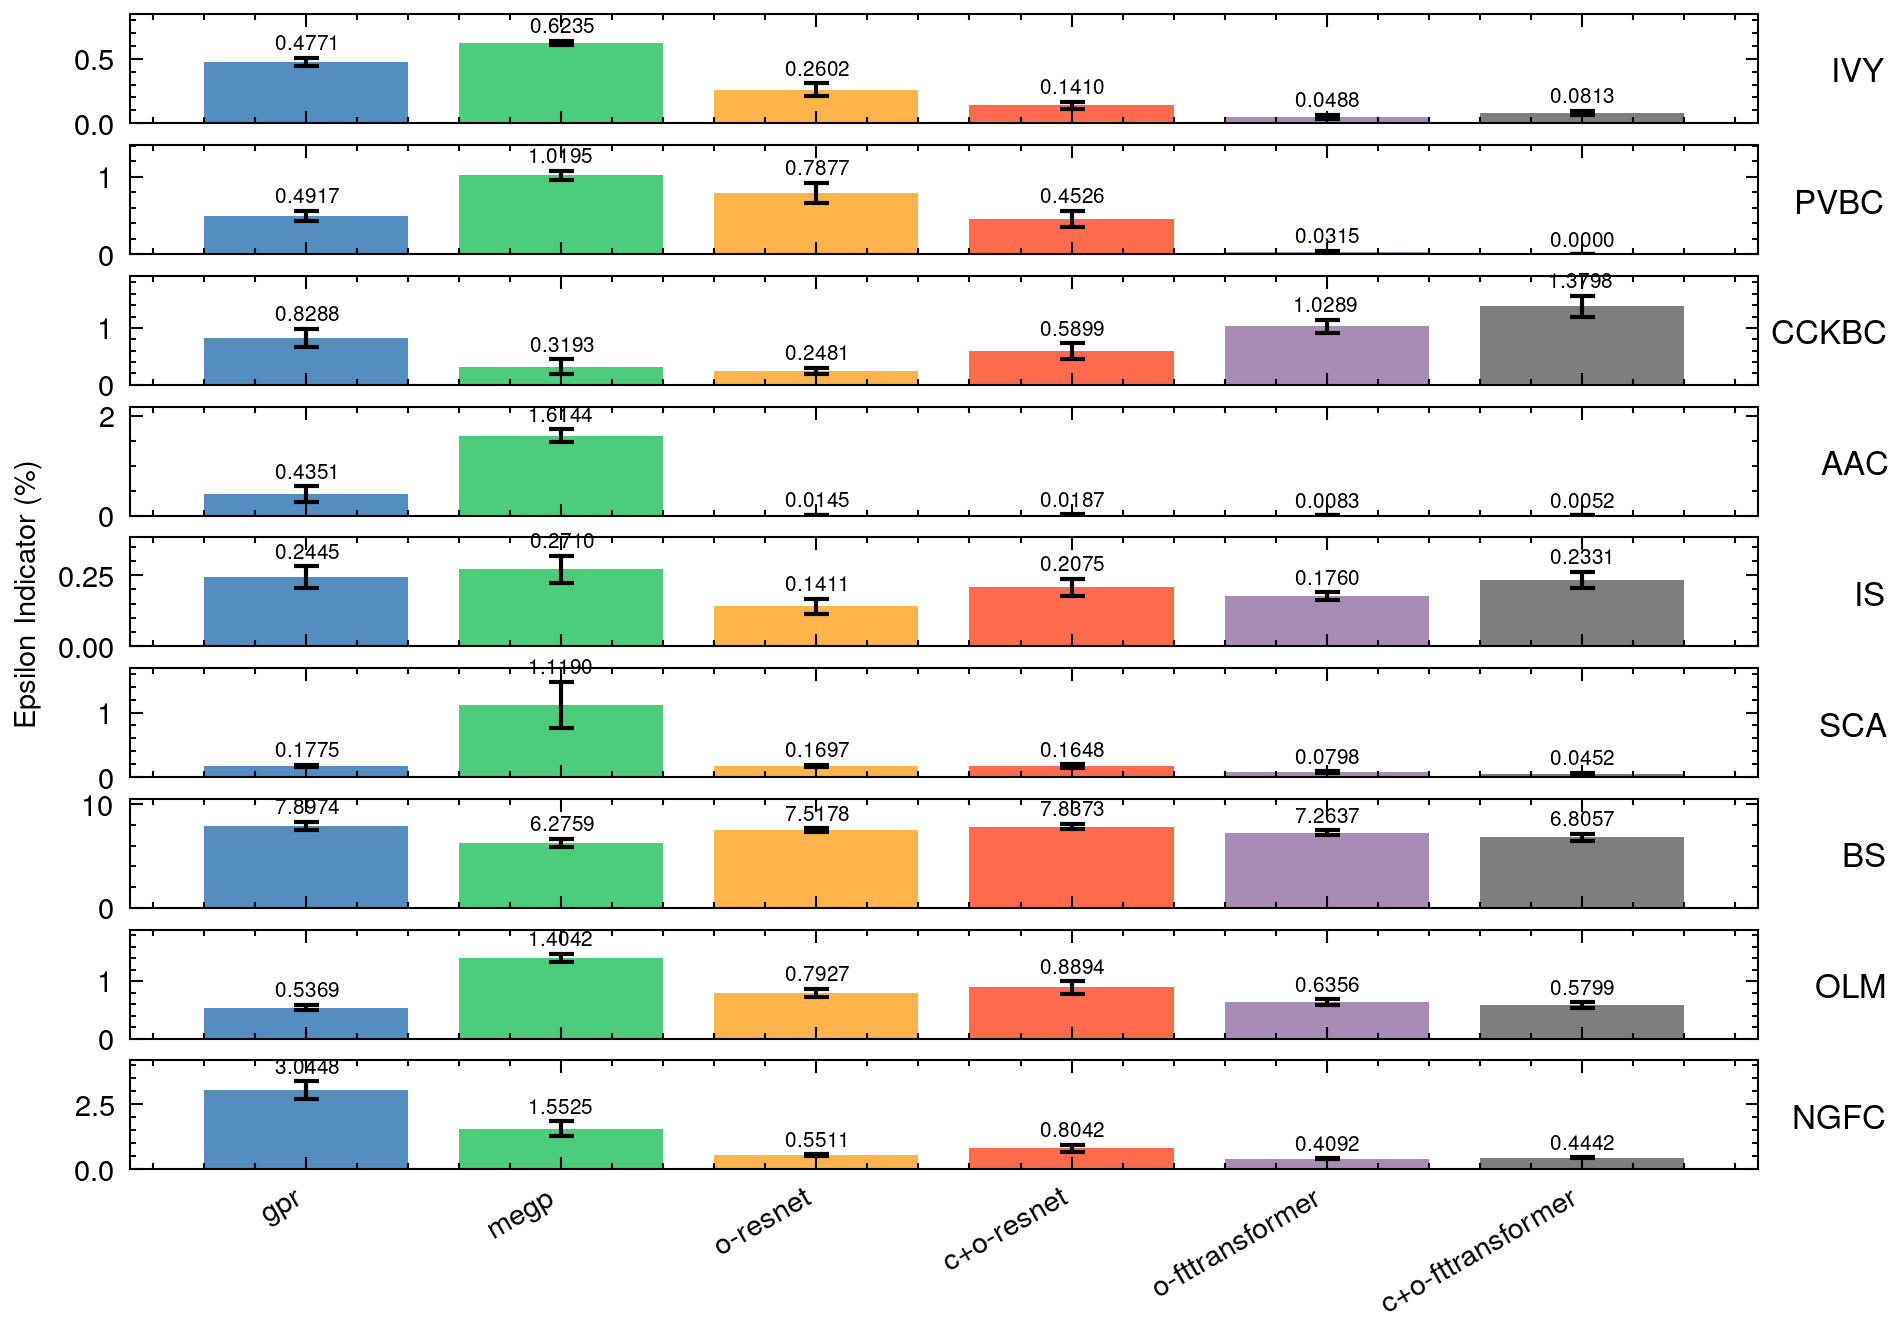

In [4]:
#len(_ca1_sopt_baseline.populations())
fig, axs = plt.subplots(9, 1, figsize=(7, 5), sharex=True)

plt.rcParams["ytick.left"] = False
plt.rcParams["ytick.right"] = False
plt.rcParams["xtick.top"] = False
plt.rcParams["xtick.bottom"] = False


i = 0
for ax, (p, d) in zip(axs, epsilon_factors.items()):
    #label = f"{p} (HV={umean(nos_hv[p]).n:.2f})"
    label = p

    bar_width = 0.35
    x = np.arange(len(d))
    y = [np.mean(v) for v in d.values()]
    yerr= [np.std(v)/len(v) for v in d.values()]
    barc = ax.bar(
        x,
        y,
        #bar_width,
        yerr=yerr,
        #label=label,
        capsize=3,
        alpha=0.7,
        color=icolors
    )
    ax.bar_label(barc, label_type='edge', fmt='%.4f', color='black', rotation=0, fontsize=5, padding=1)

    ax.set_ylim([0, (np.max(y)+np.max(yerr)/2)*1.3])
    #ax.set_yscale('log')

    #ax.legend(loc='upper right')

    ax.text(
        1.08, 0.6, label,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        horizontalalignment='right',
        #bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.3', alpha=0.8)
    )

    # ax.yaxis.set_label_coords(-0.08, 0.5)
    # ax.set_ylabel(label, rotation=0, va='center')

    i+=1

ax.set_xticks(x)
ax.set_xticklabels(list(d.keys()), rotation=30, ha='right')


axs[4].set_ylabel('Epsilon Indicator (\\%)')

plt.show()

In [13]:
stash('figure2/epsilon-performance', fig)

In [28]:
# sample difference
baseline = _ca1_sopt_baseline.components.first(
        lambda x: 'SCA' in x.label() and x.mO == '-' and not x.load_attribute("preflight", False)
    )
sopt = _ca1_sopt_baseline.components.first(
        lambda x: 'SCA' in x.label() and x.mO == 'gpr' and not x.load_attribute("preflight", False)
    )

print(baseline.num_evals_total)
print(sopt.num_evals_total)
print(baseline.num_evals_total / sopt.num_evals_total)


27900
3900
7.153846153846154


### Global summary

<>:44: SyntaxWarning: invalid escape sequence '\%'
<>:44: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_851887/2977621465.py:44: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('Epsilon Indicator (\%)')


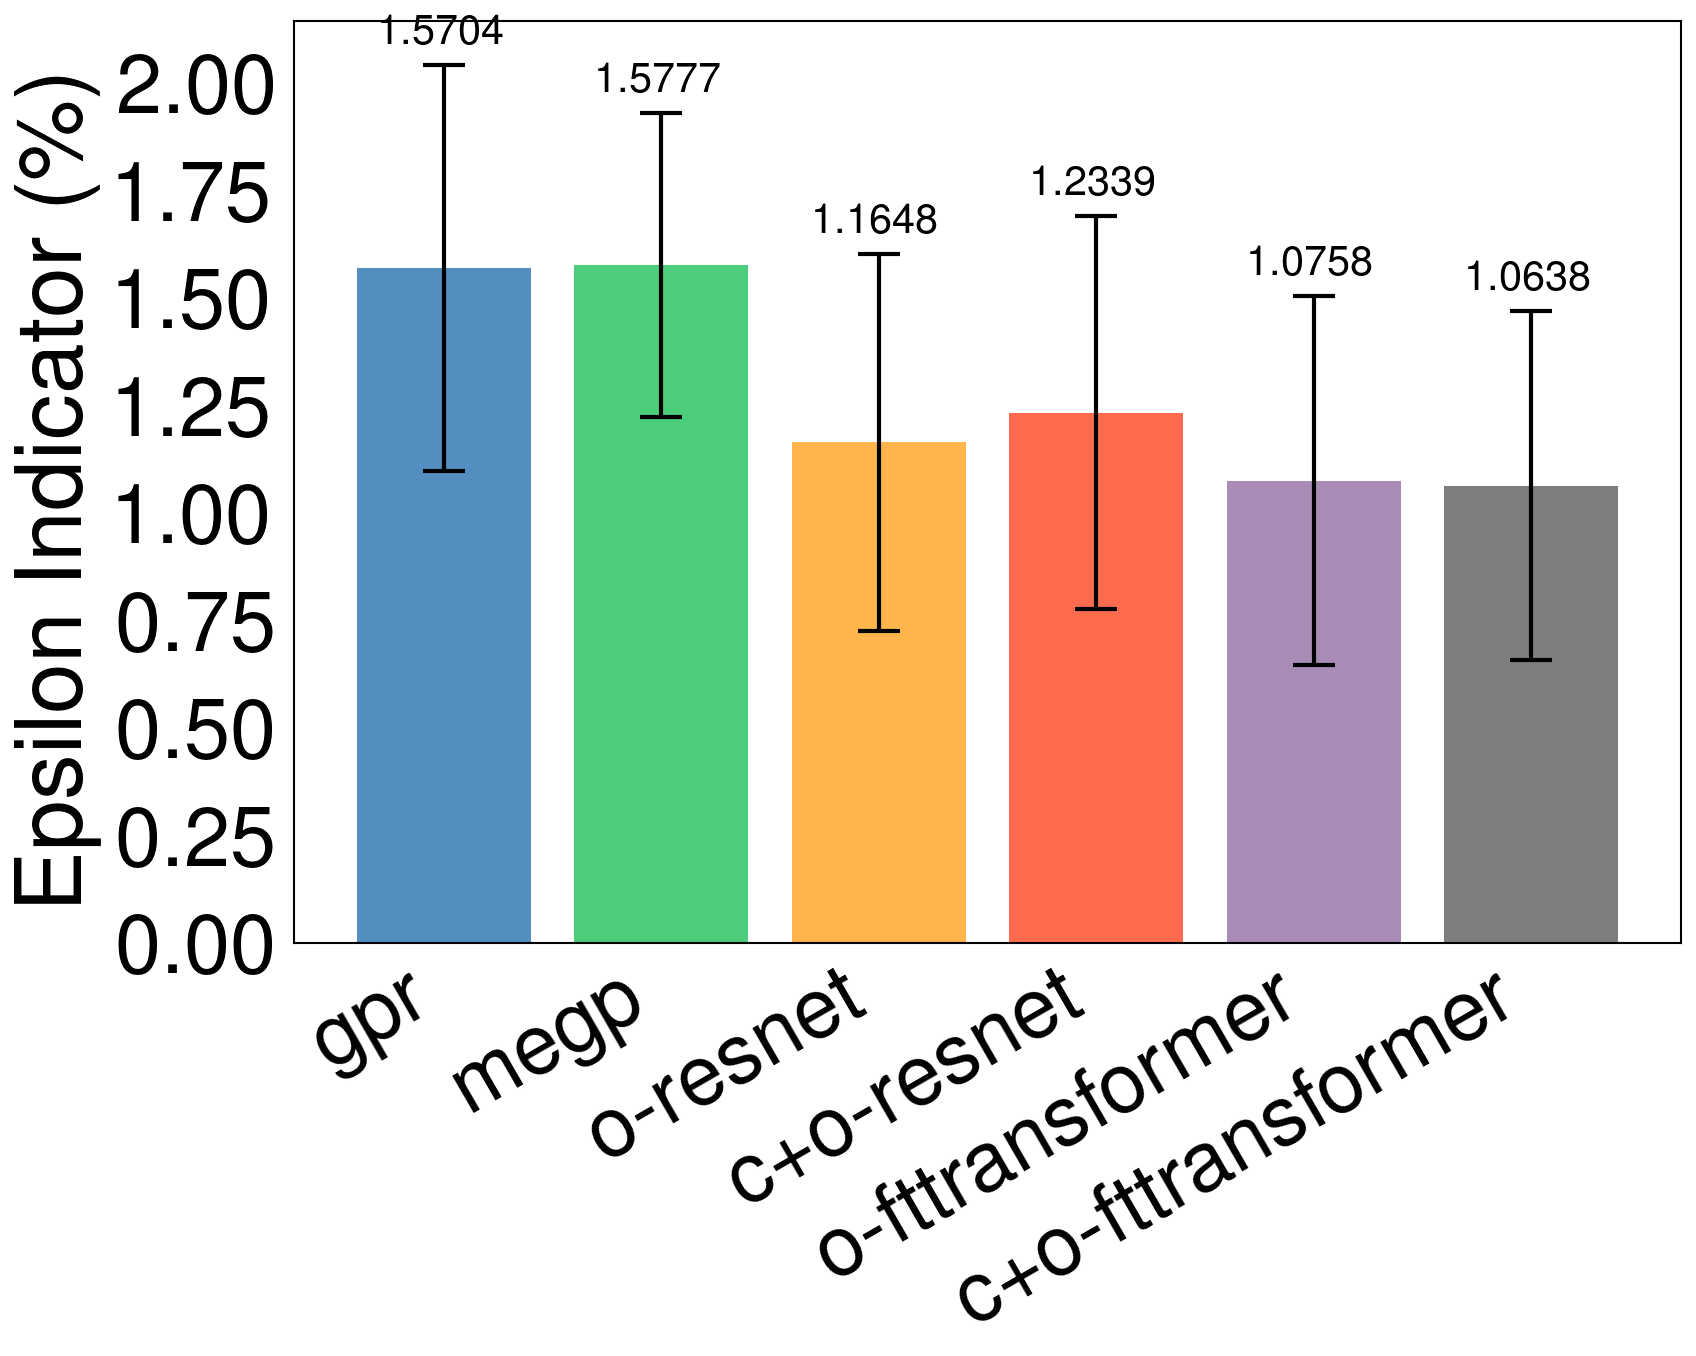

In [5]:
from collections import defaultdict
epsilon_global = defaultdict(list)
#data = {'col_1': [3, 2, 1, 0], 'col_2': ['a', 'b', 'c', 'd']}
with rc_context():
    fig, ax = plt.subplots(figsize=(6, 5))

    # Calculate mean across all cell populations for each model
    model_names = list(epsilon_factors[list(epsilon_factors.keys())[0]].keys())
    
    mean_by_model = {}
    std_by_model = {}
    
    for model in model_names:
        all_values = []
        for cell_type in epsilon_factors.keys():
            all_values.extend(epsilon_factors[cell_type][model])
        mean_by_model[model] = np.mean(all_values)
        std_by_model[model] = np.std(all_values) / np.sqrt(len(all_values))

        epsilon_global['model_name'].append(model)
        epsilon_global['eps_max'].append(np.max(np.array(all_values) / 100))
        epsilon_global['eps_min'].append(np.min(np.array(all_values) / 100))
        epsilon_global['eps_avg'].append(np.mean(np.array(all_values) / 100))
        epsilon_global['eps_std'].append(np.std(np.array(all_values) / 100) / np.sqrt(len(all_values)))
    
    x = np.arange(len(model_names))
    y = [mean_by_model[model] for model in model_names]
    yerr = [std_by_model[model] for model in model_names]
    
    bars = ax.bar(
        x,
        y,
        yerr=yerr,
        capsize=5,
        alpha=0.7,
        color=icolors[:len(model_names)]
    )
    
    # Add value labels on top of bars
    ax.bar_label(bars, label_type='edge', fmt='%.4f', fontsize=10, padding=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right')
    ax.set_ylabel('Epsilon Indicator (\%)')
    #ax.set_xlabel('Surrogate Model')
    #ax.set_title('Mean Performance Across All Cell Types')
    
    # Adjust y-limit to accommodate labels
    #ax.set_ylim([0, max(y) * 1.2])
    
    plt.tight_layout()



In [7]:
df = pd.DataFrame.from_dict(dict(epsilon_global))
df = df.sort_values(by='eps_avg', ascending=True).reset_index(drop=True)
df

,model_name,eps_max,eps_min,eps_avg,eps_std
0,c+o-fttransformer,0.082318,0.000000,0.010638,0.004060
1,o-fttransformer,0.082318,0.000000,0.010758,0.004288
2,o-resnet,0.080340,0.000093,0.011648,0.004376
3,c+o-resnet,0.086334,0.000093,0.012339,0.004578
4,gpr,0.094832,0.000903,0.015704,0.004716
5,megp,0.078335,0.000294,0.015777,0.003534


<>:191: SyntaxWarning: invalid escape sequence '\%'
<>:191: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_851887/2975970254.py:191: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel('Epsilon Indicator (\%)', size=12)


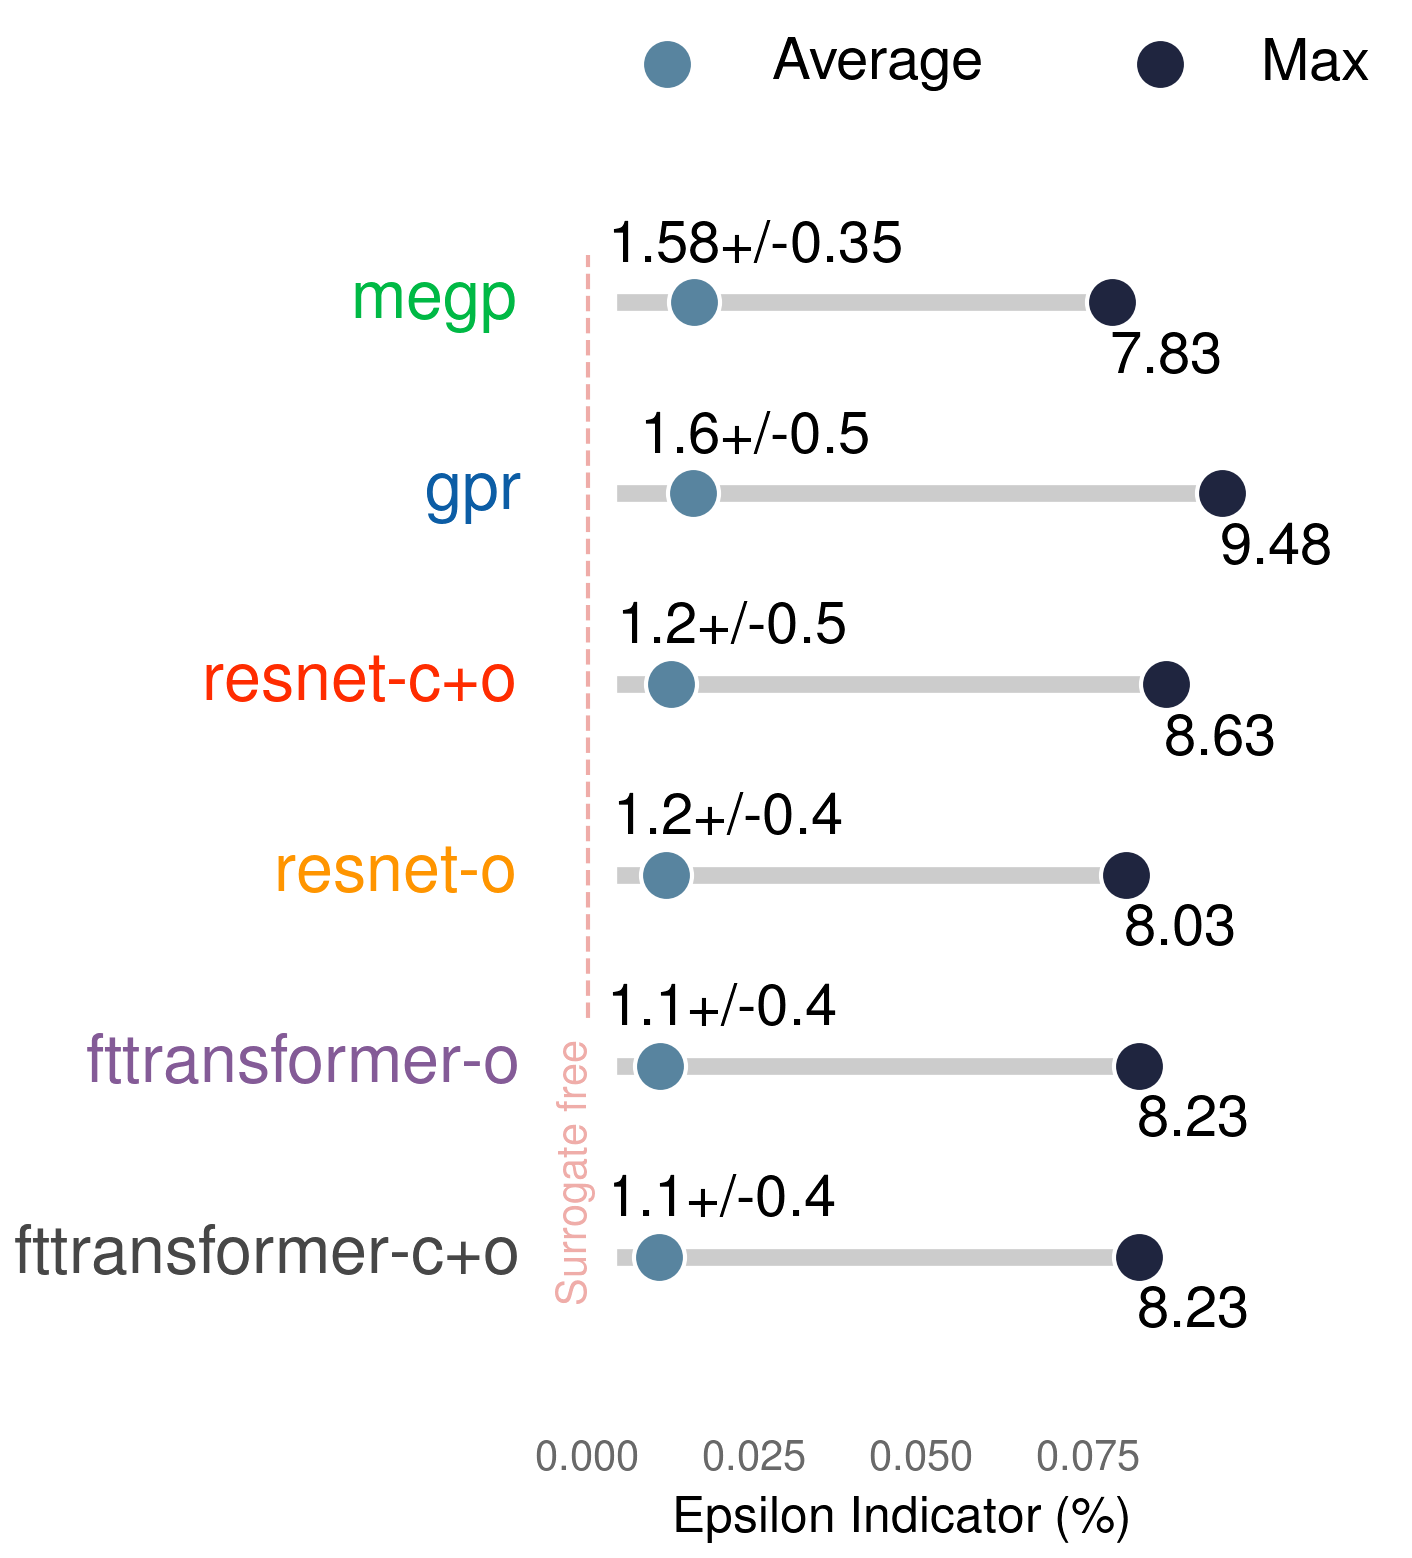

In [26]:

fig, ax = plt.subplots(1, 1, figsize=(3, 5),)



# color palette to choose from
darkblue = "#1f253f"
lightblue = "#58849f"
redish = "#d73027"

DOT_SIZE = 150

ax.scatter(
    x=df["eps_avg"],
    y=df["model_name"],
    s=DOT_SIZE,
    alpha=1,
    label="Average",
    color=lightblue,
    edgecolors="white",
)

# # min dot
# ax.scatter(
#     x=df["eps_min"],
#     y=df["model_name"],
#     s=DOT_SIZE,
#     alpha=1,
#     color=darkblue,
#     label="Min/Max",
#     edgecolors="white",
# )

# max dot
ax.scatter(
    x=df["eps_max"],
    y=df["model_name"],
    s=DOT_SIZE,
    alpha=1,
    color=darkblue,
    edgecolors="white",
    label="Max"
)

# create the horizontal line
# between min and max vals
ax.hlines(
    y=df["model_name"],
    xmin=df["eps_min"],
    xmax=df["eps_max"],
    color="grey",
    alpha=0.4,
    lw=4, # line-width
    zorder=0, # make sure line at back
)

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# plot the line that shows how a naive classifier performs
# plot two lines, one white, so that there is a gap between grid lines
# from https://stackoverflow.com/a/12731750/9214620
BASE_X = 0
ax.plot([BASE_X, BASE_X], [y_min, y_max], linestyle="-", color="white", linewidth=14)
ax.plot([BASE_X, BASE_X], [y_min, y_max], linestyle="--", color=redish, alpha=0.4,) #label="Surrogate-free")


# dictionary used to map the column labels from df to a readable name
label_dict = {
    "gpr": "GPR",
    "megp": "MEGP",
    "o-resnet": "ResNet-O",
    "c+o-resnet": "ResNet-C+O",
    "o-fttransformer": "FTTransformer-O",
    "c+o-fttransformer": "FTTransformer-C+O",
}


from uncertainties import ufloat

# iterate through each result and apply the text
# df should already be sorted
for i in range(0, df.shape[0]):
    # avg auc score
    s = ufloat(df["eps_avg"][i], df["eps_std"][i])*100

    ax.text(
        x=df["eps_avg"][i] + 0.01,
        y=i + 0.15,
        s=str(s),
        horizontalalignment="center",
        verticalalignment="bottom",
        size=14,
        color="black",
        weight="bold",

    )

    # # min auc score
    # ax.text(
    #     x=df["eps_min"][i],
    #     y=i - 0.15,
    #     s="{:.2f}".format(df["eps_min"][i]),
    #     horizontalalignment="right",
    #     verticalalignment="top",
    #     size="x-large",
    #     color="dimgrey",
    #     weight="medium",
    # )

    # max auc score
    ax.text(
        x=df["eps_max"][i],
        y=i - 0.15,
        s="{:.2f}".format(df["eps_max"][i]*100),
        horizontalalignment="left",
        verticalalignment="top",
        size=14,
        color="black",
        weight="bold",
    )

    # add thin leading lines towards classifier names
    # to the right of max dot
    # ax.plot(
    #     [df["eps_max"][i] + 0.02, 0.6],
    #     [i, i],
    #     linewidth=1,
    #     color="grey",
    #     alpha=0.4,
    #     zorder=0,
    # )
    
    # to the left of min dot
    # ax.plot(
    #     [-0.05, df["eps_min"][i] - 0.02],
    #     [i, i],
    #     linewidth=1,
    #     color="grey",
    #     alpha=0.4,
    #     zorder=0,
    # )

    # add classifier name text
    model_name = label_dict[df["model_name"][i]].lower()
    ax.text(
        x=-0.01,
        y=i,
        s=model_name,
        horizontalalignment="right",
        verticalalignment="center",
        size=16,
        color=mcolors[df["model_name"][i]],
       # weight="ultrabold",
        #rotation=30,
        )


# add text for the naive classifier
ax.text(
    x=BASE_X + 0.001,
    y=(y_min),
    s="Surrogate free",
    horizontalalignment="right",
    verticalalignment="bottom",
    size=10,
    color=redish,
    rotation="vertical",
    backgroundcolor="white",
    alpha=0.4,
)

# remove the y ticks
ax.set_yticks([])

# drop the gridlines (inherited from 'seaborn-whitegrid' style)
# and drop all the spines
ax.grid(False)  
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# custom set the xticks since this looks better
#ax.set_xticks([0.0, 0.2, 0.4, 0.6])

# set properties of xtick labels
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.tick_params.html#matplotlib.axes.Axes.tick_params
ax.tick_params(axis="x", pad=20, labelsize="x-large", labelcolor="dimgrey")


ax.set_xlabel('Epsilon Indicator (\%)', size=12)


# create legend
ax.legend(
    frameon=False,
    bbox_to_anchor=(0., 1.05),
    ncol=2,
    fontsize=14,
    labelcolor="black",
)

# plt.savefig('best_results.svg',dpi=150, bbox_inches = "tight")


In [27]:
stash('figure2/epsilon-global-v2', fig)

## Online accuracy

In [ ]:
surrogate_accuracy = {"data": {}}

_ca1_sopt_baseline = get("interface._ca1_sopt_baseline", {"selection": (None,)})

for p in _ca1_sopt_baseline.populations():
    experiments = _ca1_sopt_baseline.components.filter(lambda x: x.cached() and p in x.label())

    yy = []
    for experiment in experiments:
        h5 = experiment.load_h5()
        yy.append(h5["predictions"].to_numpy()[experiment.num_initial_samples :])
        yy.append(h5["objectives"].to_numpy()[experiment.num_initial_samples :])
    if len(yy) == 0:
        continue
    yy = np.vstack(yy)
    yy = yy[~np.isnan(yy)]
    yy_mean = np.mean(yy, axis=0)
    yy_std = np.std(yy, axis=0)

    def norm(y):
        return (y - yy_mean) / (yy_std + 1e-9)

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        cell_type = cell_type.replace("CA1_", "")
        sampler_name = model_type[2:].split("/")[0].replace("joint-", "")
        trial = experiment.context.predicate.trial

        surrogate_accuracy["n_initial"] = n_initial = experiment.num_initial_samples
        surrogate_accuracy["data"].setdefault(cell_type, {})
        surrogate_accuracy["data"][cell_type].setdefault(sampler_name, {})

        h5 = experiment.load_h5()
        y_pred = norm(h5["predictions"].to_numpy()[n_initial:])
        y = norm(h5["objectives"].to_numpy()[n_initial:])

        nmae = np.abs(y - y_pred)

        N = int(experiment.num_evals_per_epoch * (experiment.num_evals_per_epoch - 1))
        nmae = np.pad(nmae, ((0, N - nmae.shape[0]), (0, 0)), constant_values=np.nan)

        # average in chunks of a 100
        surrogate_accuracy["chunk_size"] = chunk_size = 100
        start = 0  # experiment.num_initial_samples
        surrogate_accuracy["num"] = num = len(nmae) - start
        cutoff = num - (num % chunk_size)
        end = start + cutoff
        surrogate_accuracy["num_"] = end
        d = surrogate_accuracy["data"][cell_type][sampler_name]
        for i, col in enumerate(h5["objectives"].columns):
            d.setdefault(col, [])
            reduce = np.nanmean(nmae[start:end, i].reshape(-1, chunk_size), axis=1)
            d[col].append(reduce)

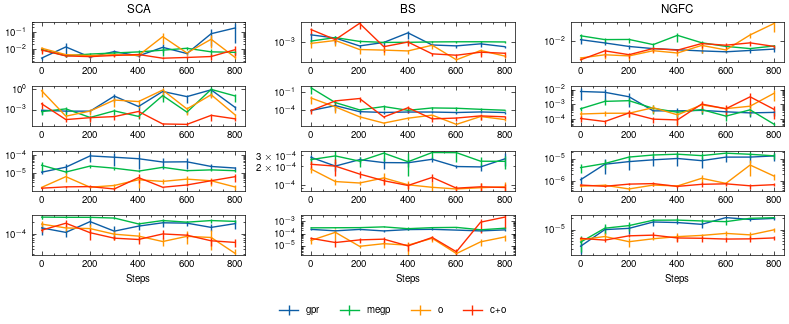

In [ ]:
fig, axs = plt.subplots(
    4, len(surrogate_accuracy["data"]), figsize=(8, 3), sharey=False
)

for ax, (cell_type, models) in zip(axs.T, surrogate_accuracy["data"].items()):
    for sampler_name, metric_name in models.items():
        c = 0
        for field, mm in metric_name.items():
            mm = np.array(mm)
            x = np.arange(
                0, surrogate_accuracy["num_"], surrogate_accuracy["chunk_size"]
            )
            y = mm.mean(axis=0)
            y_err = mm.std(axis=0) / np.sqrt(len(mm))

            ax[c].errorbar(x, y, yerr=y_err, label=sampler_name)
            ax[c].set_yscale("log")
            c += 1

    ax[-1].set_xlabel("Steps")
    # ax.set_ylim(0, 100)
    ax[0].set_title(cell_type)

# axs[0].set_ylabel('Normalized Mean Absolute Error')

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

stash("figure2/single-cells-surrogate-accuracy", fig)